In [24]:
import numpy as np
import math
import h5py
import sys
from sys import argv, exit
import configparser
from mpi4py import MPI
import meep as mp
import os
from numpy import array
from matplotlib.colors import LogNorm
from math import pi

from os.path import join
from matplotlib import pyplot as pl
from scipy.signal import butter, lfilter
import utils_CFM
import util_nuRadioMC

from pathlib import Path
import utils_CFM
#from utils_CFM import fluence, get_2peaks, shift_t

sys.path.append('../../')
from paraPropPython import paraProp as ppp
import receiver as rx
from transmitter import tx_signal
from data import create_sim, create_rxList_from_file, create_tx_signal, create_transmitter_array
from data import create_hdf_bscan, bscan_rxList, create_hdf_FT
import util
from util import cut_arr2, cut_arr, findNearest
from data import ascan

def getNearest(y_arr, x_arr, x):
    ii = findNearest(x_arr, x)
    return y_arr[ii]

from fluence_analysis import *
#from fluence_plotting import *

path_EisEik = 'IceEikonal'
sys.path.append(path_EisEik)
from ray_solver import ray_path_theta
from medium import exp_profile1, get_profile_from_data, get_dndz, rho2n_kovacs

def get_ray_path(theta_t, tx_position, ds, z_vec, n_vec, dndz_vec, bounds, r_max = 500., factor = 3):
    xt, zt = tx_position[0], tx_position[1]
    #r_direct = np.sqrt((xr-xt)**2 + (zr-zt)**2)
    nSteps = factor * int(r_max/ds) # Path length must be less than 3 times the direct distance
    ray_path_l = ray_path_theta(x_start=xt, z_start=zt, theta_start=theta_t,
                                ds=ds, nSteps=nSteps,
                                z_vec=z_vec, n_vec=n_vec, dndz_vec=dndz_vec,
                                bounds=bounds)
    return ray_path_l

def get_t_cut(x):
    x0 = 220
    x1 = 300
    x2 = 360
    t0 = 1925
    t1 = 2200
    t2 = 2450
    if x <= x0:
        t_cut = t0 + ((x-x0)/20)*100
    elif x < x2 and x > x0:
        t_cut = t1 + ((x-x1)/20)*100
    else:
        t_cut = t2 + ((x-x2)/20)*100
    return t_cut

In [25]:
fname_config_meep = 'config_files/config_analysis_askaryan_500_meep_years.txt'

meep_data = get_sim_meep(fname_config_meep)
ascan_meep0, tspace_meep0, rxList_meep0, sourceDepth_meep0 = meep_data

nRx0 = len(rxList_meep0)
nSims = len(ascan_meep0)
nSamples = len(tspace_meep0)


fname_l, label_l = get_fname_l(fname_config=fname_config_meep)
fname_0 = fname_l[0]

nSamples = len(tspace_meep0)
nSims = len(ascan_meep0)
nRx = len(rxList_meep0)
print('nSims =',nSims, 'nSamples =', nSamples, 'nRx =', nRx)
print(ascan_meep0[0].shape)
x_rx_un = np.unique(rxList_meep0[:,0])
z_rx_un = np.unique(rxList_meep0[:,1])
print(x_rx_un)
for i in range(len(z_rx_un)):
    print(i, z_rx_un[i])

#Calculate Energy Uncertainty
rxPulses_meep_l = []
x_limit_l = [160, 540]
z_limit_l = [0, 160]
X_min_pl = 160
X_max_pl = 500 #520
Z_min_pl = 4 #0
Z_max_pl = 160 #180

t_shift = 50
print(rxList_meep0.shape)
for i in range(nSims):
    rxPulses_meep_i = ascan_meep0[i]
    print(rxPulses_meep_i.shape)
    rxPulses_meep, rxList_meep = convert_rxPulses(rxPulses_meep_i, tspace_meep0, rxList_meep0, x_limit_l, z_limit_l, t_shift=t_shift)
    print(rxPulses_meep.shape)
    rxPulses_meep_l.append(rxPulses_meep)

t_limit_arr_full = np.zeros((nRx0, 2))
for i in range(nRx0):
    x_rx = rxList_meep0[i, 0]
    t_limit_arr_full[i, 1] = get_t_cut(x_rx)

#t_limits = np.zeros((nRx,2))
nRx = len(rxList_meep)
print(rxList_meep)
t_limit_arr = np.zeros((nRx, 2))
for i in range(nRx):
    x_rx = rxList_meep[i,0]
    t_limit_arr[i,1] = get_t_cut(x_rx)
    print(x_rx, t_limit_arr[i])
#exit()

rxPulse0 = rxPulses_meep_l[0]
rxFluence0 = np.zeros(nRx)
for i in range(nRx):
    #print(t_limit_arr[i])
    rxPulse_cut = utils_CFM.cut_arr(rxPulse0[i], tspace_meep0, 0, t_limit_arr[i,1])
    #print(rxPulse_cut)
    #rxPulse_cut = rxPulse0[i]
    rxFluence0[i] = np.sum(abs(rxPulse_cut))
x_rx_arr = rxList_meep[:,0]
z_rx_arr = rxList_meep[:,1]
x_rx_un2 = np.unique(x_rx_arr)
z_rx_un2 = np.unique(z_rx_arr)
nRx_x = len(x_rx_un2)
nRx_z = len(z_rx_un2)
color_l = ['g', 'purple']

override_bool = True
interp_mode = 'spline36' #None # 'spline36'
plot_fluence_bool = True

absorb_mode 0
airHeight 50.0
boreholeRadius 0.15
decimation_factor 5.0
dpml 40.0
dt 0.2777777777777778
dt_meep 0.016666666666666666
dt_ns_res 0.05555555555555556
freq_samp 18.0
iceDepth 250.0
iceRange 550.0
n_buffer 1000
pad 40.0
res 30.0
sourceDepth 90.0
sourceRange 0.075
0 load mmap data_meep/500m_160m_tx90_askaryan_2/CFM_analysis_2010_7_corr_z_tx_90.0_dtheta=7.5_askaryan_buffer
1 load mmap data_meep/500m_160m_tx90_askaryan_2/CFM_analysis_2011_7_corr_z_tx_90.0_dtheta=7.5_askaryan_buffer
2 load mmap data_meep/500m_160m_tx90_askaryan_2/CFM_analysis_2012_7_corr_z_tx_90.0_dtheta=7.5_askaryan_buffer
3 load mmap data_meep/500m_160m_tx90_askaryan_2/CFM_analysis_2013_7_corr_z_tx_90.0_dtheta=7.5_askaryan_buffer
4 load mmap data_meep/500m_160m_tx90_askaryan_2/CFM_analysis_2014_7_corr_z_tx_90.0_dtheta=7.5_askaryan_buffer
5 load mmap data_meep/500m_160m_tx90_askaryan_2/CFM_analysis_2015_7_corr_z_tx_90.0_dtheta=7.5_askaryan_buffer
6 load mmap data_meep/500m_160m_tx90_askaryan_2/CFM_analysis_2016_

28.0
No Reflection

28.25
No Reflection

28.500000000000004
No Reflection

28.750000000000007
No Reflection

29.000000000000004
No Reflection

29.25
No Reflection

29.500000000000004
No Reflection

29.750000000000007
No Reflection

30.000000000000004
No Reflection

30.25
No Reflection

30.500000000000004
No Reflection

30.750000000000007
No Reflection

31.000000000000007
No Reflection

31.250000000000004
No Reflection

31.500000000000007
No Reflection

31.75000000000001
No Reflection

32.00000000000001
No Reflection

32.25000000000001
No Reflection

32.50000000000001
No Reflection

32.750000000000014
No Reflection

33.00000000000001
No Reflection

33.25000000000001
No Reflection

33.50000000000001
No Reflection

33.750000000000014
No Reflection

34.00000000000001
No Reflection

34.25000000000001
No Reflection

34.50000000000001
No Reflection

34.750000000000014
No Reflection

35.000000000000014
No Reflection

35.25000000000001
No Reflection

35.500000000000014
No Reflection

35.7500000

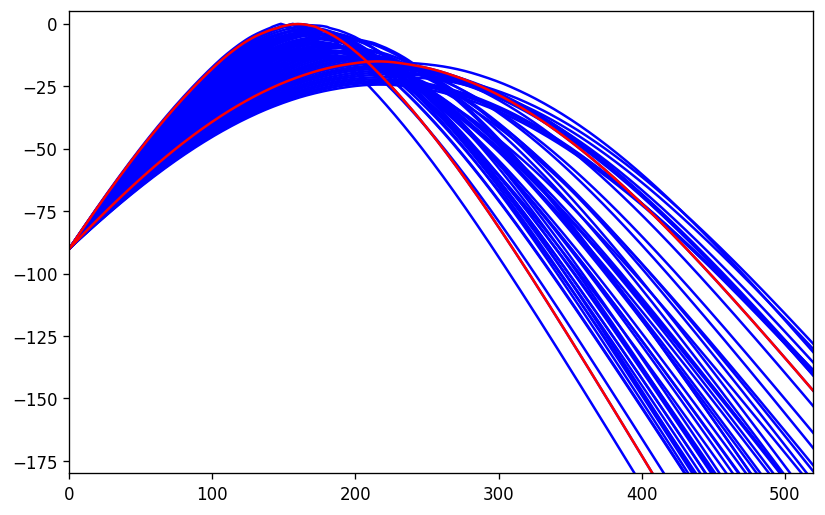

In [26]:
# For performing Ray Tracing
prof0_data = np.genfromtxt('nProf_CFM_2015_1.txt')
#n_prof0, z_prof0 = utils_CFM.get_nProfiles_from_file(fname_hdf=fname_0)
n_prof0 = prof0_data[:,1]
z_prof0 = prof0_data[:,0]

n_prof_cut, z_prof_cut = utils_CFM.cut_arr2(n_prof0, z_prof0,0, 200)
z_prof_RT = -1*np.flip(z_prof_cut)
n_prof_RT = np.flip(n_prof_cut)
dndz_RT = get_dndz(z_prof_RT, n_prof_RT)

bnds_RT = [0, 520, -180, 5]
ds = 0.5
r_max = 500.
factor = 2
tx_pos_RT = [0, -sourceDepth_meep0]
from functools import partial
get_ray_final2 = partial(get_ray_path, tx_position=tx_pos_RT, ds=ds, z_vec=z_prof_RT, n_vec=n_prof_RT, dndz_vec=dndz_RT, bounds=bnds_RT, r_max=r_max, factor=factor)
theta_min = np.deg2rad(28)
theta_max = np.deg2rad(41)
dtheta = np.deg2rad(0.25)
theta_space = np.arange(theta_min, theta_max, dtheta)
nTheta = len(theta_space)
fig = pl.figure(figsize=(8,5),dpi=120)
ax = fig.add_subplot(111)

theta_id2 = []
theta_l2 = []
z_max_l2 = []
x_path_l2 = []
z_path_l2 = []

x_ray_all = []
z_ray_all =[]

for i in range(nTheta):
    ray_path_i = get_ray_final2(theta_space[i])
    print(np.rad2deg(theta_space[i]))
    x_path_l, z_path_l = [], []
    nRefl_l = []
    for j in range(len(ray_path_i)):
        ray_j = ray_path_i[j]
        nRefl_l.append(ray_j.nRefl)
        x_path_l.append(ray_j.x)
        z_path_l.append(ray_j.z)
        x_ray_all.append(ray_j.x)
        z_ray_all.append(ray_j.z)
        #print(ray_j.x, ray_j.z)
    #print(x_path_l, z_path_l)
    #print(nRefl_l)
    if np.max(nRefl_l) == 1:
        print('Reflection')
    else:
        print('No Reflection')
        z_max_l2.append(np.max(z_path_l))
        theta_l2.append(theta_space[i])
        theta_id2.append(i)
        x_path_l2.append(x_path_l)
        z_path_l2.append(z_path_l)
    print('')
    ax.plot(x_path_l, z_path_l, c='b')
ii_z0 = np.argmax(np.array(z_max_l2))
ii_z15 = np.argmin(abs(-15 - np.array(z_max_l2)))
theta_id_z0 = theta_id2[ii_z0]
theta_id_z15 = theta_id2[ii_z15]
print(np.rad2deg(theta_l2[ii_z0]), np.rad2deg(theta_l2[ii_z15]))

x_path_z0 = np.array(x_path_l2[ii_z0])
z_path_z0 = np.array(z_path_l2[ii_z0])
x_path_z15 = np.array(x_path_l2[ii_z15])
z_path_z15 = np.array(z_path_l2[ii_z15])
ax.plot(x_path_z0, z_path_z0,c='r')
ax.plot(x_path_z15, z_path_z15,c='r')

ax.set_xlim(bnds_RT[0], bnds_RT[1])
ax.set_ylim(bnds_RT[2], bnds_RT[3])
pl.show()

In [27]:
path2plot = 'CFM_2015_tx90_pl_yrs_3'
if os.path.isdir(path2plot) == False:
    os.system('mkdir ' + path2plot)
import time
# Get rxFluences
t_cut = 15
t_ratio = 1
pl_bool = True

rxPulses_meep_l = []
x_limit_l = [160, 540]
z_limit_l = [0, 160]
X_min_pl = 160
X_max_pl = 500 #520
Z_min_pl = 4 #0
Z_max_pl = 160 #180

'''
x_limit_l = [300, 520]
z_limit_l = [0, 180]
'''
t_shift = 50
print(rxList_meep0.shape)
for i in range(nSims):
    rxPulses_meep_i = ascan_meep0[i]
    print(rxPulses_meep_i.shape)
    rxPulses_meep, rxList_meep = convert_rxPulses(rxPulses_meep_i, tspace_meep0, rxList_meep0, x_limit_l, z_limit_l, t_shift=t_shift)
    print(rxPulses_meep.shape)
    rxPulses_meep_l.append(rxPulses_meep)

t_limit_arr_full = np.zeros((nRx0, 2))
for i in range(nRx0):
    x_rx = rxList_meep0[i, 0]
    t_limit_arr_full[i, 1] = get_t_cut(x_rx)

#t_limits = np.zeros((nRx,2))
nRx = len(rxList_meep)
print(rxList_meep)
t_limit_arr = np.zeros((nRx, 2))
for i in range(nRx):
    x_rx = rxList_meep[i,0]
    t_limit_arr[i,1] = get_t_cut(x_rx)
    print(x_rx, t_limit_arr[i])
#exit()

rxPulse0 = rxPulses_meep_l[0]
rxFluence0 = np.zeros(nRx)
for i in range(nRx):
    #print(t_limit_arr[i])
    rxPulse_cut = utils_CFM.cut_arr(rxPulse0[i], tspace_meep0, 0, t_limit_arr[i,1])
    #print(rxPulse_cut)
    #rxPulse_cut = rxPulse0[i]
    rxFluence0[i] = np.sum(abs(rxPulse_cut))
x_rx_arr = rxList_meep[:,0]
z_rx_arr = rxList_meep[:,1]
x_rx_un2 = np.unique(x_rx_arr)
z_rx_un2 = np.unique(z_rx_arr)
nRx_x = len(x_rx_un2)
nRx_z = len(z_rx_un2)
hist2d, x_bins, z_bins = np.histogram2d(x_rx_arr, z_rx_arr, bins=(nRx_x, nRx_z), weights=rxFluence0)
hist2d = np.transpose(hist2d)
'''
fig = pl.figure(figsize=(8,5),dpi=120)
ax = fig.add_subplot(111)
pmesh = ax.imshow(hist2d, aspect='auto', extent=[x_limit_l[0], x_limit_l[1], z_limit_l[1], z_limit_l[0]], interpolation='sinc')
cbar = fig.colorbar(pmesh)
ax.set_xlabel('Range x [m]')
ax.set_ylabel('Depth z [m]')
pl.show()'''

color_l = ['g', 'purple']

override_bool = True
interp_mode = 'spline36' #None # 'spline36'
plot_fluence_bool = True

(2597, 2)
(2597, 12922)
(1443, 12922)
(2597, 12922)
(1443, 12922)
(2597, 12922)
(1443, 12922)
(2597, 12922)
(1443, 12922)
(2597, 12922)
(1443, 12922)
(2597, 12922)
(1443, 12922)
(2597, 12922)
(1443, 12922)
(2597, 12922)
(1443, 12922)
(2597, 12922)
(1443, 12922)
(2597, 12922)
(1443, 12922)
(2597, 12922)
(1443, 12922)
[[160.   4.]
 [160.   8.]
 [160.  12.]
 ...
 [520. 148.]
 [520. 152.]
 [520. 156.]]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.]
160.0 [   0. 1625.

In [28]:
print('Calculate FLuence for R and D')
tstart =time.time()
rxFluence_meep, rxList_meep = get_fluence_matrix_list(rxPulses_meep_l, rxList_meep, tspace_meep0,
                                                      t_cut=t_cut, t_ratio=t_ratio,
                                                      fname_npy='meep_fl_500.npy', 
                                                      override=override_bool, ppp_mode=False, t_limit_in=t_limit_arr)
tend = time.time()
print('load time', tend-tstart)

rxFluence_meep_tot, rxList_meep = get_fluence_matrix_list(rxPulses_meep_l, rxList_meep, tspace_meep0,
                                                          t_cut=t_cut, t_ratio=t_ratio, tot_mode=True,
                                                          fname_npy='meep_fl_tot_500.npy', override=override_bool, ppp_mode=False, t_limit_in=t_limit_arr)

rxFluence_meep_var = calculate_variance_matrix(rxFluence_meep)
rxFluence_meep_tot_var = calculate_variance_matrix(rxFluence_meep_tot, tot_mode=True)

Calculate FLuence for R and D
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
load time 16.78169274330139
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter
f1 None f2 None
No filter


(1000, 600)


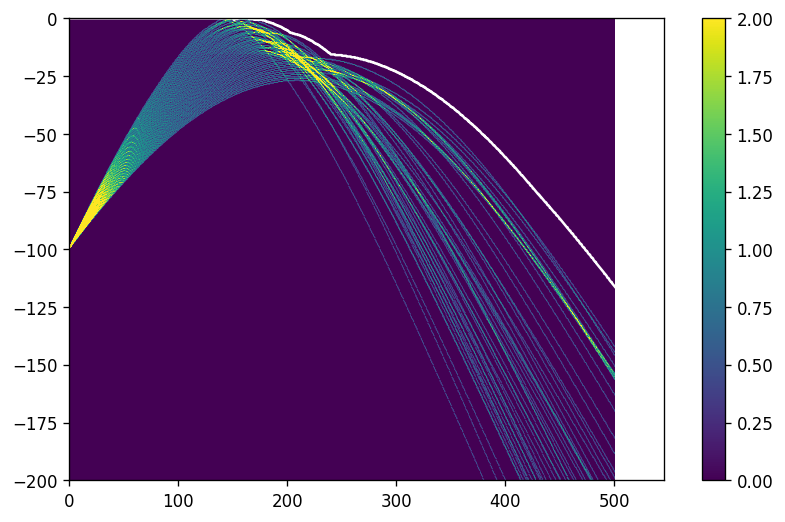

(11, 1443, 2)
(1443, 2)
(1443, 2)


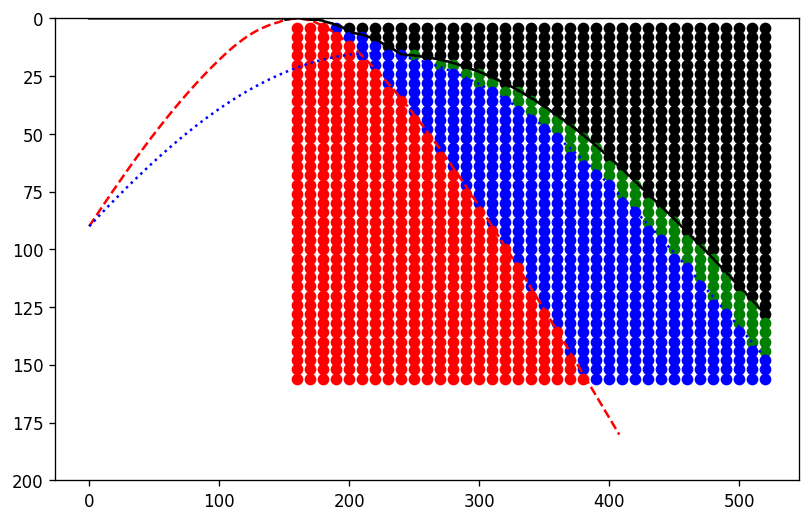

0.03293106711845313
0.19114702568701186
0.27009206761244353
(1000, 600)


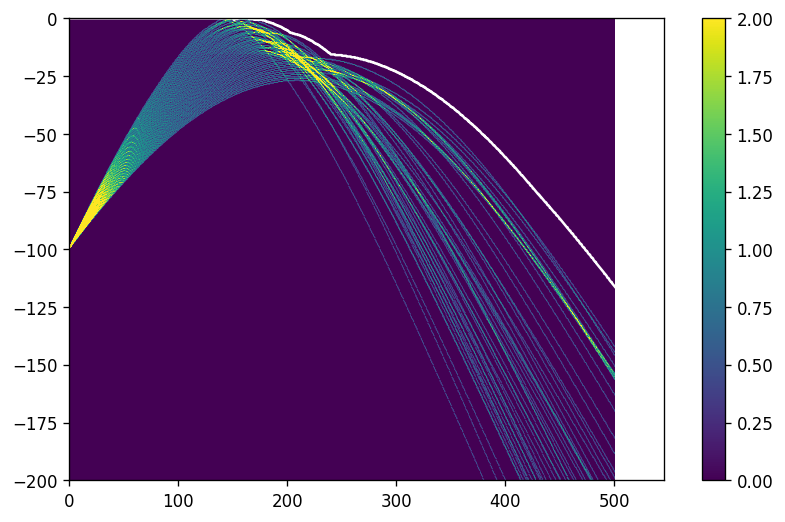

(11, 1443, 2)
(1443, 2)
(1443, 2)


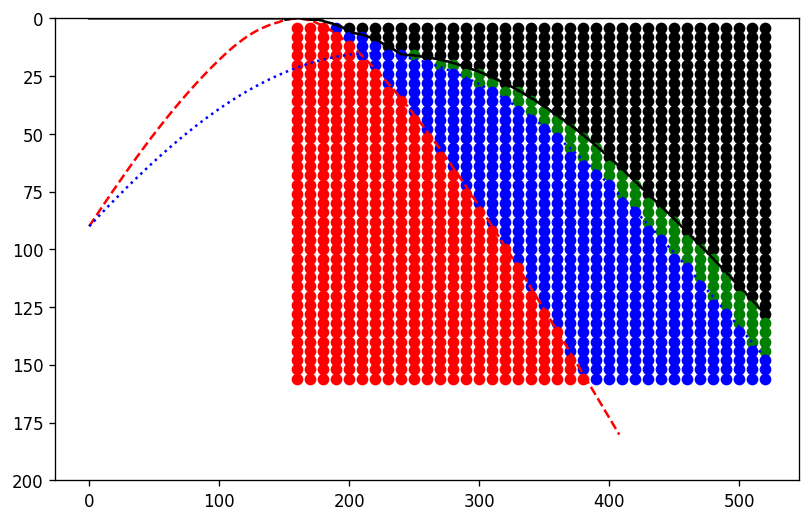

0.03293106711845313
0.19114702568701186
0.27009206761244353


In [41]:
nBins_x = 1000
nBins_z = 600
hist2d_ray, x_bins, z_bins = np.histogram2d(x_ray_all, z_ray_all, bins=(nBins_x, nBins_z))
print(hist2d_ray.shape,)

fig = pl.figure(figsize=(8,5),dpi=120)
ax = fig.add_subplot(111)
pmesh = ax.imshow(np.transpose(hist2d_ray), aspect='auto', extent=[0, 500, 0, -200], cmap='viridis', vmax=2, vmin=0)
ax.set_ylim(-200, 0)
cbar = fig.colorbar(pmesh)

z_shadow = []
x_shadow = []
for i in range(nBins_x):
    x_shadow.append(x_bins[i])
    if x_bins[i] > 150:
        hist2d_zslice = np.flip(hist2d_ray[i,:])
        z_bins_flip = np.flip(z_bins)
        for j in range(nBins_z):
            if hist2d_zslice[j] > 0:
                z_shadow.append(z_bins_flip[j])
                break
    else:
        z_shadow.append(0)
ax.plot(x_shadow, z_shadow, c='w')
pl.show()   

# Calculate between lines
print(rxFluence_meep.shape)

print(rxFluence_meep_var.shape)
print(rxList_meep.shape)

#print(x_path_z0, -1*z_path_z0)


rxFluence_var_meep0 = []# reflection
rxFluence_var_meep1 = [] # Refraction
rxFluence_var_meep2 = [] # Refraction

rxFluence_D_var_meep0 = []# reflection
rxFluence_D_var_meep1 = [] # Refraction
rxFluence_D_var_meep2 = [] # Refraction

rxFluence_tot_var_meep0 = []# reflection
rxFluence_tot_var_meep1 = [] # Refraction
rxFluence_tot_var_meep2 = [] # Refraction


fluence_var_refr = 0
fig = pl.figure(figsize=(8,5),dpi=120)
ax = fig.add_subplot(111)
for i in range(nRx):
    x_rx = rxList_meep[i,0]
    z_rx = rxList_meep[i,1]

    ii_x0 = findNearest(x_rx, x_path_z0)
    ii_x15 = findNearest(x_rx, x_path_z15)
    ii_xsh = findNearest(x_rx, x_shadow)
    
    x_guess0 = x_path_z0[ii_x0]
    z_guess0 = -1*z_path_z0[ii_x0]

    x_guess15 = x_path_z15[ii_x15]
    z_guess15 = -1*z_path_z15[ii_x15]

    x_guess_sh = x_shadow[ii_xsh]
    z_guess_sh = -1*z_shadow[ii_xsh]
    #print(z_guess_sh)

    if z_rx < z_guess_sh: # and z_rx > 15:
        ax.scatter(x_rx, z_rx, c='k')
        rxFluence_var_meep2.append(rxFluence_meep_var[i,1])
        rxFluence_D_var_meep2.append(rxFluence_meep_var[i,0])
        rxFluence_tot_var_meep2.append(rxFluence_meep_tot_var[i])

    else:
        if z_rx >= z_guess0:# and z_rx > 15:
            ax.scatter(x_rx, z_rx, c='r')
            rxFluence_var_meep0.append(rxFluence_meep_var[i,1])
            rxFluence_D_var_meep0.append(rxFluence_meep_var[i,0])
            rxFluence_tot_var_meep0.append(rxFluence_meep_tot_var[i])

        else:
            if z_rx <= z_guess15 and x_rx >= 250: #and z_rx < 15:
                ax.scatter(x_rx, z_rx, c='g')
            else:
                ax.scatter(x_rx, z_rx, c='b')
                rxFluence_var_meep1.append(rxFluence_meep_var[i,1])
                rxFluence_D_var_meep1.append(rxFluence_meep_var[i,0])
                rxFluence_tot_var_meep1.append(rxFluence_meep_tot_var[i])
    

ax.plot(x_path_z0, -1*z_path_z0, '--', c='r',label='Refracted, $z_{max} = 0 \, \mathrm{m}$')
ax.plot(x_path_z15, -1*z_path_z15, ':', c='b',label='Refracted, $z_{max} = 15 \, \mathrm{m}$')
ax.plot(x_shadow, -1*np.array(z_shadow), c='k')

ax.set_ylim(200,0)
pl.show()

print(np.nanmean(rxFluence_var_meep0))
print(np.nanmean(rxFluence_var_meep1))
print(np.nanmean(rxFluence_var_meep2))

nBins_x = 1000
nBins_z = 600
hist2d_ray, x_bins, z_bins = np.histogram2d(x_ray_all, z_ray_all, bins=(nBins_x, nBins_z))
print(hist2d_ray.shape,)

fig = pl.figure(figsize=(8,5),dpi=120)
ax = fig.add_subplot(111)
pmesh = ax.imshow(np.transpose(hist2d_ray), aspect='auto', extent=[0, 500, 0, -200], cmap='viridis', vmax=2, vmin=0)
ax.set_ylim(-200, 0)
cbar = fig.colorbar(pmesh)

z_shadow = []
x_shadow = []
for i in range(nBins_x):
    x_shadow.append(x_bins[i])
    if x_bins[i] > 150:
        hist2d_zslice = np.flip(hist2d_ray[i,:])
        z_bins_flip = np.flip(z_bins)
        for j in range(nBins_z):
            if hist2d_zslice[j] > 0:
                z_shadow.append(z_bins_flip[j])
                break
    else:
        z_shadow.append(0)
ax.plot(x_shadow, z_shadow, c='w')
pl.show()   

# Calculate between lines
print(rxFluence_meep.shape)

print(rxFluence_meep_var.shape)
print(rxList_meep.shape)

#print(x_path_z0, -1*z_path_z0)


rxFluence_var_meep0 = []# reflection
rxFluence_var_meep1 = [] # Refraction
rxFluence_var_meep2 = [] # Refraction

rxFluence_D_var_meep0 = []# reflection
rxFluence_D_var_meep1 = [] # Refraction
rxFluence_D_var_meep2 = [] # Refraction

rxFluence_tot_var_meep0 = []# reflection
rxFluence_tot_var_meep1 = [] # Refraction
rxFluence_tot_var_meep2 = [] # Refraction

shadow_mode_map = np.full(nRx, np.nan)


fluence_var_refr = 0
fig = pl.figure(figsize=(8,5),dpi=120)
ax = fig.add_subplot(111)
for i in range(nRx):
    x_rx = rxList_meep[i,0]
    z_rx = rxList_meep[i,1]

    ii_x0 = findNearest(x_rx, x_path_z0)
    ii_x15 = findNearest(x_rx, x_path_z15)
    ii_xsh = findNearest(x_rx, x_shadow)
    
    x_guess0 = x_path_z0[ii_x0]
    z_guess0 = -1*z_path_z0[ii_x0]

    x_guess15 = x_path_z15[ii_x15]
    z_guess15 = -1*z_path_z15[ii_x15]

    x_guess_sh = x_shadow[ii_xsh]
    z_guess_sh = -1*z_shadow[ii_xsh]
    #print(z_guess_sh)

    if z_rx < z_guess_sh: # and z_rx > 15:
        shadow_mode_map[i] = 0
        ax.scatter(x_rx, z_rx, c='k')
        rxFluence_var_meep2.append(rxFluence_meep_var[i,1])
        rxFluence_D_var_meep2.append(rxFluence_meep_var[i,0])
        rxFluence_tot_var_meep2.append(rxFluence_meep_tot_var[i])

    else:
        shadow_mode_map[i] = 1
        if z_rx >= z_guess0:# and z_rx > 15:
            ax.scatter(x_rx, z_rx, c='r')
            rxFluence_var_meep0.append(rxFluence_meep_var[i,1])
            rxFluence_D_var_meep0.append(rxFluence_meep_var[i,0])
            rxFluence_tot_var_meep0.append(rxFluence_meep_tot_var[i])

        else:
            if z_rx <= z_guess15 and x_rx >= 250: #and z_rx < 15:
                ax.scatter(x_rx, z_rx, c='g')
            else:
                ax.scatter(x_rx, z_rx, c='b')
                rxFluence_var_meep1.append(rxFluence_meep_var[i,1])
                rxFluence_D_var_meep1.append(rxFluence_meep_var[i,0])
                rxFluence_tot_var_meep1.append(rxFluence_meep_tot_var[i])
    

ax.plot(x_path_z0, -1*z_path_z0, '--', c='r',label='Refracted, $z_{max} = 0 \, \mathrm{m}$')
ax.plot(x_path_z15, -1*z_path_z15, ':', c='b',label='Refracted, $z_{max} = 15 \, \mathrm{m}$')
ax.plot(x_shadow, -1*np.array(z_shadow), c='k')

ax.set_ylim(200,0)
pl.show()

print(np.nanmean(rxFluence_var_meep0))
print(np.nanmean(rxFluence_var_meep1))
print(np.nanmean(rxFluence_var_meep2))

In [30]:
#TODO: FInish function - make plots of R and D
def get_fluence_at_depth_local(rxFluence, rxList, z_rx):
    x_rx_all = rxList[:,0]
    z_rx_all = rxList[:,1]
    x_rx_un = np.unique(x_rx_all)
    z_rx_un = np.unique(z_rx_all)

    ii_z = util.findNearest(z_rx_un, z_rx)
    z_rx_actual = z_rx_un[ii_z]
        
    nRx_x = len(x_rx_un)
    nSims = rxFluence.shape[0]
    if len(rxFluence.shape) == 3:
        nShape = 2
        rxFluence_at_z = np.zeros((nSims, nRx_x,2))
    else:
        nShape = 1
        rxFluence_at_z = np.zeros((nSims, nRx_x))
    for i in range(nRx_x):
        ii_rx = utils_CFM.get_index_from_rxList(rxList, x_rx_un[i], z_rx_actual)
        if nShape == 1:
            rxFluence_at_z[:,i] = rxFluence[:,ii_rx]
        else:
            rxFluence_at_z[:,i,:] = rxFluence[:,ii_rx,:]
    return rxFluence_at_z, x_rx_un, z_rx_actual

z_rx_select = 100
z_rx_actual = z_rx_select
#print('z_rx_actual', z_rx_actual)

label_refl = '$x_{L}(z)$'
label_refr_sh = '$x_{R,15}(z)$'
label_shadow = '$x_{S}(z)$'

label_refl_b = '$\mathbf{x_{L}(z)}$'
label_refr_sh_b = '$\mathbf{x_{R,15}(z)}$'
label_shadow_b = '$\mathbf{x_{S}(z)}$'

# Get The range of the Refl -> Refr transition + Refr. -> Shadow transition
x_rx_refl_refr = getNearest(x_path_z0, -1*z_path_z0, z_rx_actual)
x_rx_refr_15 = getNearest(x_path_z15, -1*z_path_z15, z_rx_actual)

#print(x_shadow.type, z_shadow.type)
x_shadow = np.array(x_shadow)
z_shadow = np.array(z_shadow)
x_rx_refr_shadow = getNearest(x_shadow, -1*z_shadow, z_rx_actual)
print(x_rx_refl_refr, x_rx_refr_15, x_rx_refr_shadow)

321.20775689006217 447.80046681191527 473.0574539073851


(11, 37)
37
(11, 37)
(11, 37)
37
(11, 37)


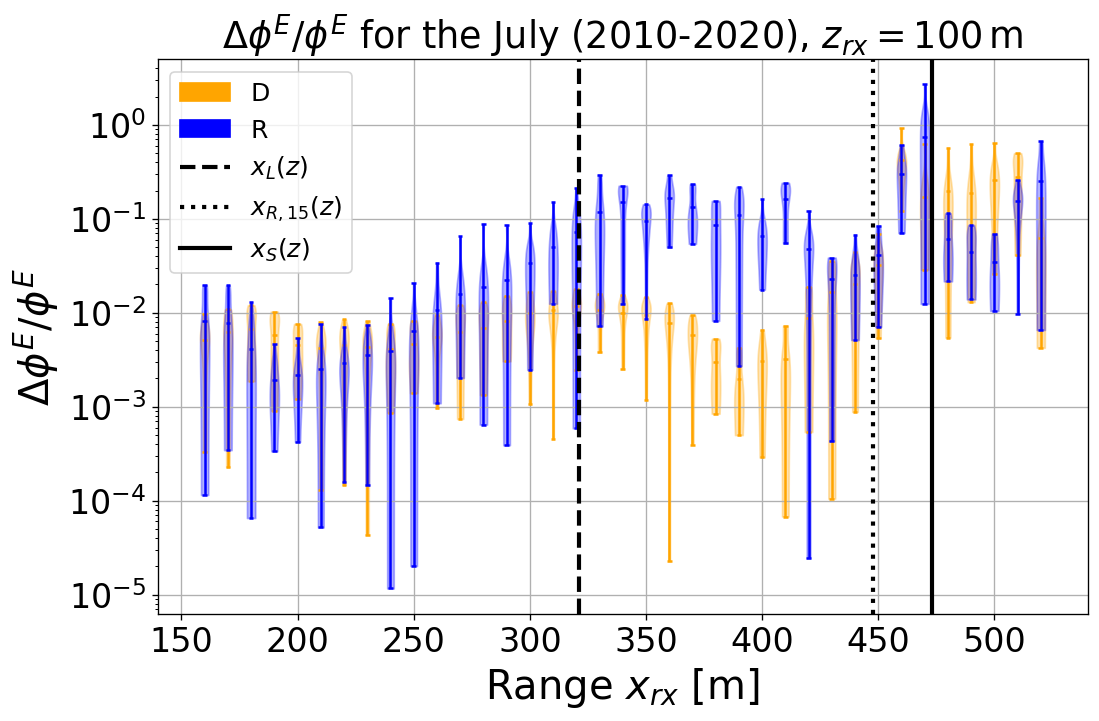

In [32]:
rxFluence_at_z0, x_rx_un, z_rx_act = get_fluence_at_depth_local(rxFluence_meep, rxList_meep, z_rx_select)

labels = []
label_l = ['D','R']
color_list = ['orange','b']
fig = pl.figure(figsize=(10,6),dpi=120)
ax = fig.add_subplot(111)
for i in range(2):
    rxFluence_at_z_i = rxFluence_at_z0[:,:,i]
    print(rxFluence_at_z_i.shape)
    nRx_x = rxFluence_at_z_i.shape[1]
    nSims_i = rxFluence_at_z_i.shape[0]
    print(nRx_x)
    #rx_fluence_residual = np.zeros((nSims, nRx_x))
    #rx_fluence_variance = np.zeros((nRx_x, 2))

    rxFluence_violin = []
    rxFluence_mean = []
    rxFluence_std = []
    print(rxFluence_at_z_i.shape)
    for j in range(nRx_x):
        #print(rxFluence_at_x[k,i])
        #rxFluence_violin.append(rxFluence_at_z_i[:,j])
        rxFluence_mean_j = np.mean(rxFluence_at_z_i[:,j])
        rxFluence_std_j = np.std(rxFluence_at_z_i[:,j])

        rxFluence_mean.append(rxFluence_mean_j)
        rxFluence_std.append(rxFluence_std_j)
        rx_fluence_residual = []
        for k in range(nSims_i):
            rx_fluence_residual.append(abs(rxFluence_at_z_i[k,j]-rxFluence_mean_j)/rxFluence_mean_j)
        rxFluence_violin.append(rx_fluence_residual)
    vio = ax.violinplot(dataset=rxFluence_violin, positions=x_rx_un, showmeans=True,widths=4)
    for partname in ('cmeans', 'cmins', 'cmaxes', 'cbars'):
        vp_line = vio.get(partname)
        if vp_line is not None:
            if isinstance(vp_line, list):
                for line in vp_line:
                    line.set_color(color_list[i])
            else:
                vp_line.set_color(color_list[i])
    for pc in vio['bodies']:
        pc.set_facecolor(color_list[i])
        pc.set_edgecolor(color_list[i])
    label_i = label_l[i]
    add_label(vio, label_i,labels)
ax.set_title('$\Delta \phi^{E}/\phi^{E}$ for the July (2010-2020), $z_{rx} = ' + str(z_rx_select) + ' \, \mathrm{m}$',fontsize=22)
ax.grid()

group_proxies = []
for i in range(2):
    ...
    # after styling the violin:
    group_proxies.append(
        mpatches.Patch(facecolor=color_list[i], edgecolor=color_list[i], label=label_l[i])
    )

# add vertical lines with labels (as you already do)
line1 = ax.axvline(x_rx_refl_refr, c='k', linestyle='--', label=label_refl,linewidth=2.5)
line2 = ax.axvline(x_rx_refr_15,  c='k', linestyle=':',  label=label_refr_sh,linewidth=2.5)
line3 = ax.axvline(x_rx_refr_shadow, c='k', linestyle='-', label=label_shadow,linewidth=2.5)

# now combine
line_handles, line_labels = ax.get_legend_handles_labels()  # includes axvline's
handles = group_proxies + line_handles
labels  = [p.get_label() for p in group_proxies] + line_labels
ax.legend(handles, labels, fontsize=15, loc='upper left')
ax.set_yscale('log')

ax.set_xlabel('Range $x_{rx}$ [m]',fontsize=24)
ax.set_ylabel('$\Delta \phi^{E}/\phi^{E}$',fontsize=24)
ax.tick_params(axis='both',labelsize=20)
fig.savefig(join(path2plot,'rx_fluence_at_zrx_vio_' + str(int(str(z_rx_select))) + '_m.png'), bbox_inches='tight')

pl.show()

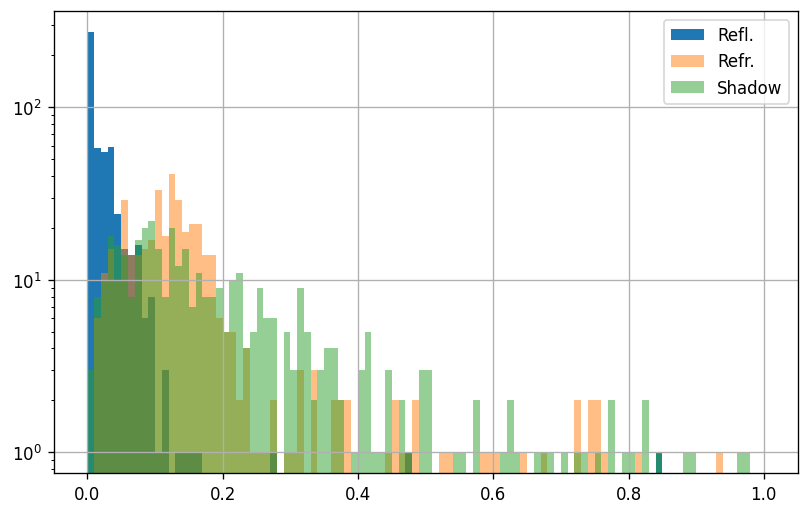

Reflection zone, mean: 3.2931 %, median: 0.9968 %
Refraction zone, mean: 19.1147 %, median: 12.4995 %
Shadow zone, mean: 27.0092 %, median: 15.2849 %


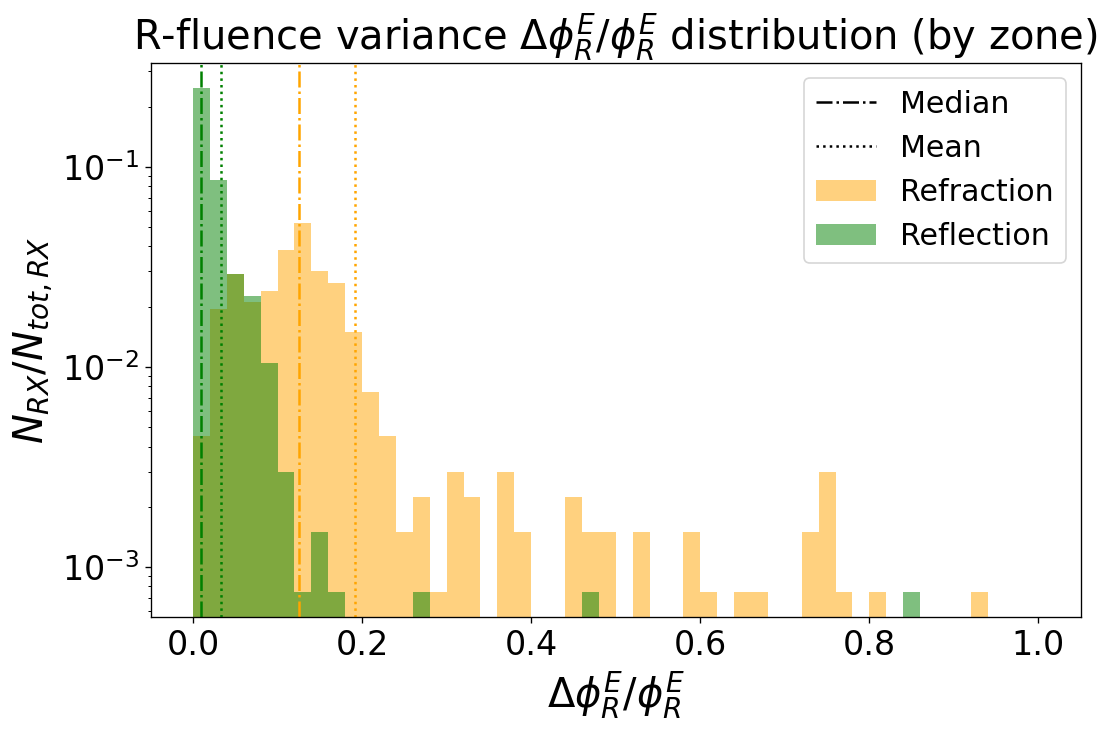

In [33]:
fontsize = 24
labelsize = 20
legsize = 18

fig = pl.figure(figsize=(8,5),dpi=120)
ax = fig.add_subplot(111)
ax.hist(rxFluence_var_meep0, range=(0,1),bins=100,label='Refl.')
ax.hist(rxFluence_var_meep1, range=(0,1),bins=100,label='Refr.',alpha=0.5)
ax.hist(rxFluence_var_meep2, range=(0,1),bins=100,label='Shadow',alpha=0.5)
ax.set_yscale('log')
ax.grid()
ax.legend()
pl.show()

print('Reflection zone, mean:', round(np.nanmean(rxFluence_var_meep0)*100,4), '%, median:', round(np.nanmedian(rxFluence_var_meep0)*100,4), '%')
print('Refraction zone, mean:', round(np.nanmean(rxFluence_var_meep1)*100,4), '%, median:', round(np.nanmedian(rxFluence_var_meep1)*100,4), '%')
print('Shadow zone, mean:', round(np.nanmean(rxFluence_var_meep2)*100,4), '%, median:', round(np.nanmedian(rxFluence_var_meep2)*100, 4), '%')

nBins = 50
xrange = (0,1)
x_width = abs(xrange[1] - xrange[0])
#Linear Histograms
hist1d_lin_var_meep_2, x_bins = np.histogram(rxFluence_var_meep2, range=xrange,bins=nBins)
hist1d_lin_var_meep_1, x_bins = np.histogram(rxFluence_var_meep1, range=xrange,bins=nBins)
hist1d_lin_var_meep_0, x_bins = np.histogram(rxFluence_var_meep0, range=xrange,bins=nBins)

sum_total = np.sum(hist1d_lin_var_meep_0) + np.sum(hist1d_lin_var_meep_1) + np.sum(hist1d_lin_var_meep_2)

x_cent = (x_bins[1:] + x_bins[:-1]) /2

fig = pl.figure(figsize=(10,6),dpi=120)
ax = fig.add_subplot(111)
ax.set_title('R-fluence variance $\Delta \phi^{E}_{R}/\phi^{E}_{R}$ distribution (by zone)',fontsize=fontsize)
#ax.bar(x_cent, hist1d_lin_var_meep_2/sum_total, width=x_width/float(nBins), label='Shadow',alpha=1,color='b')
ax.bar(x_cent, hist1d_lin_var_meep_1/sum_total, width=x_width/float(nBins), label='Refraction',alpha=0.5,color='orange')
ax.bar(x_cent, hist1d_lin_var_meep_0/sum_total, width=x_width/float(nBins), label='Reflection',alpha=0.5,color='g')

ax.axvline(np.nan,color='k', label='Median',linestyle='dashdot')
ax.axvline(np.nan,color='k', label='Mean',linestyle=':')

#ax.axvline(np.nanmedian(rxFluence_var_meep2),color='b',linestyle='dashdot')
ax.axvline(np.nanmedian(rxFluence_var_meep1),color='orange',linestyle='dashdot')
ax.axvline(np.nanmedian(rxFluence_var_meep0),color='g',linestyle='dashdot')

#ax.axvline(np.nanmean(rxFluence_var_meep2),color='b',linestyle=':')
ax.axvline(np.nanmean(rxFluence_var_meep1),color='orange',linestyle=':')
ax.axvline(np.nanmean(rxFluence_var_meep0),color='g',linestyle=':')
ax.set_yscale('log')
ax.set_xlabel('$\Delta \phi^{E}_{R}/\phi^{E}_{R}$',fontsize=fontsize)
ax.set_ylabel('$N_{RX}/N_{tot,RX}$',fontsize=fontsize)
#ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=labelsize)
#ax.grid()
ax.legend(fontsize=legsize)
fig.savefig('fl_rx_distribution_years_lin.png',bbox_inches='tight')
pl.show()

nBins = 20
xrange = (-3.5,0.5)
x_width = abs(xrange[1] - xrange[0])
# Log 10 histograms
hist1d_var_meep_2, x_bins = np.histogram(np.log10(rxFluence_var_meep2), range=xrange,bins=nBins)
hist1d_var_meep_1, x_bins = np.histogram(np.log10(rxFluence_var_meep1), range=xrange,bins=nBins)
hist1d_var_meep_0, x_bins = np.histogram(np.log10(rxFluence_var_meep0), range=xrange,bins=nBins)

sum_total = np.sum(hist1d_var_meep_0) + np.sum(hist1d_var_meep_1) + np.sum(hist1d_var_meep_2)

x_cent = (x_bins[1:] + x_bins[:-1]) /2

Tot-mode
Reflection zone, mean: 0.9656 %, median: 0.6555 %
Refraction zone, mean: 3.0664 %, median: 2.0999 %
Shadow zone, mean: 16.6233 %, median: 12.5777 %


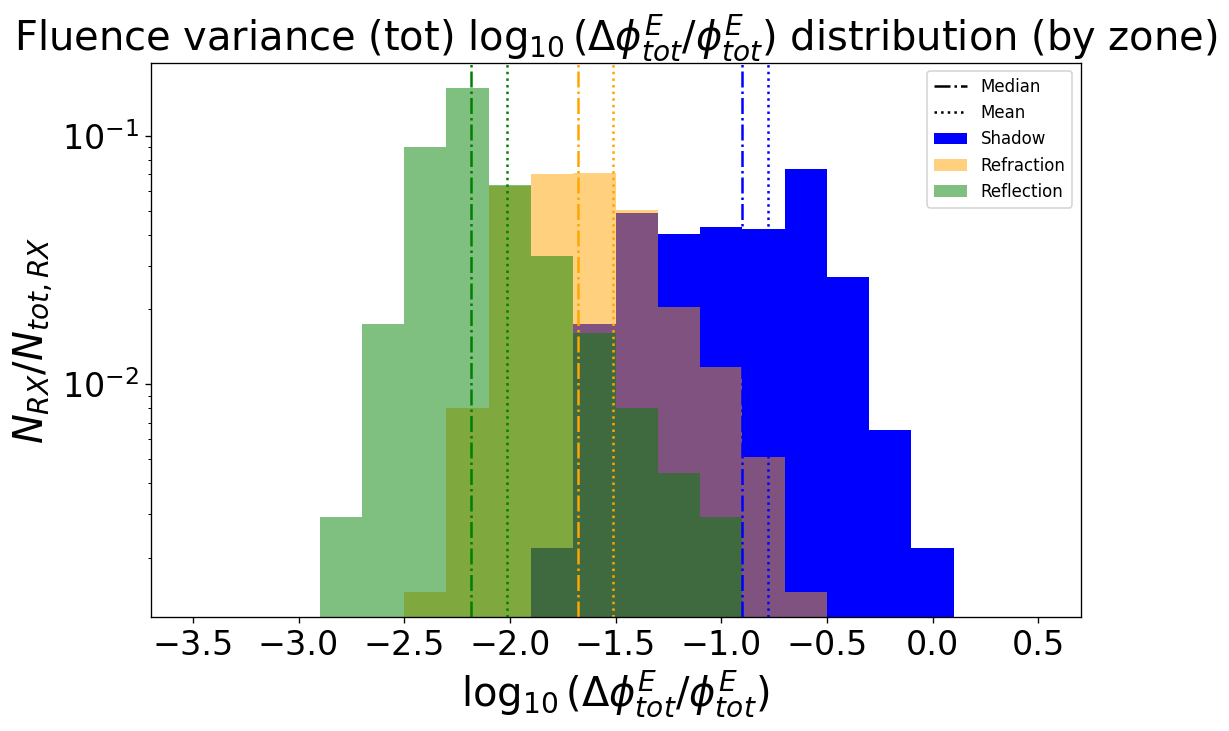

Tot-mode
Reflection zone, mean: 0.9656 %, median: 0.6555 %
Refraction zone, mean: 3.0664 %, median: 2.0999 %
Shadow zone, mean: 16.6233 %, median: 12.5777 %


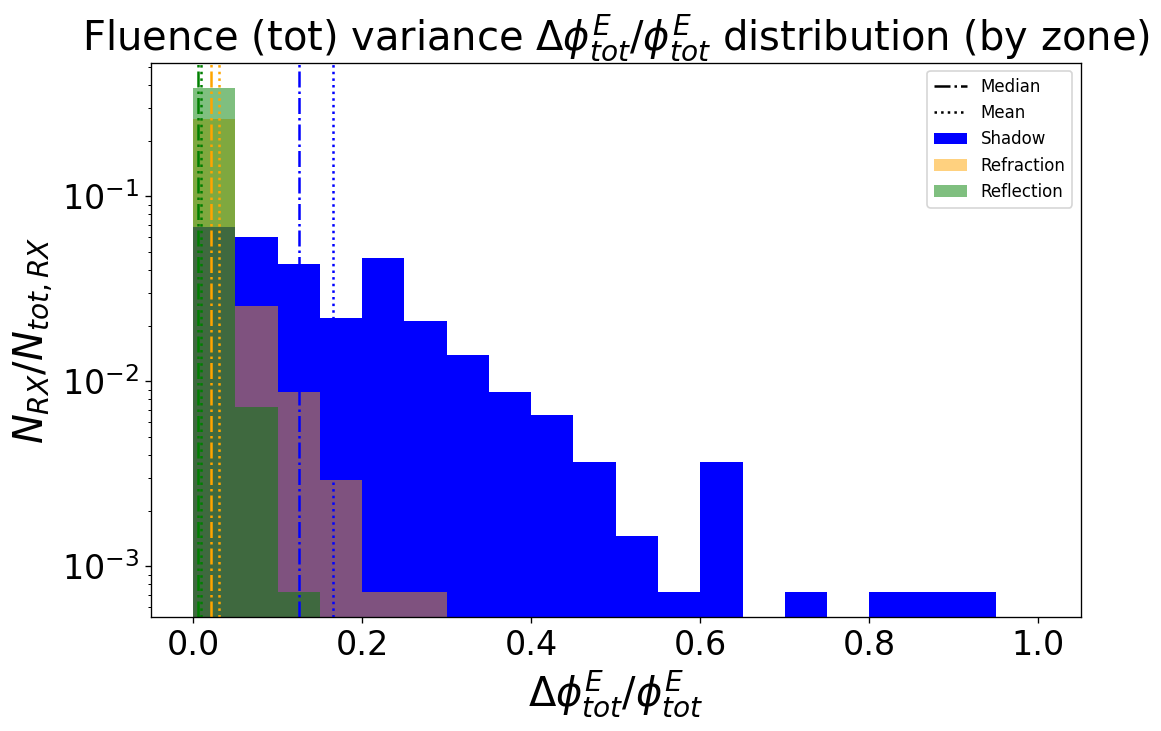

In [34]:
print('Tot-mode')
print('Reflection zone, mean:', round(np.nanmean(rxFluence_tot_var_meep0)*100,4), '%, median:', round(np.nanmedian(rxFluence_tot_var_meep0)*100,4), '%')
print('Refraction zone, mean:', round(np.nanmean(rxFluence_tot_var_meep1)*100,4), '%, median:', round(np.nanmedian(rxFluence_tot_var_meep1)*100,4), '%')
print('Shadow zone, mean:', round(np.nanmean(rxFluence_tot_var_meep2)*100,4), '%, median:', round(np.nanmedian(rxFluence_tot_var_meep2)*100, 4), '%')

nBins = 20
xrange = (-3.5,0.5)
x_width = abs(xrange[1] - xrange[0])
hist1d_var_meep_2, x_bins = np.histogram(np.log10(rxFluence_tot_var_meep2), range=xrange,bins=nBins)

hist1d_var_meep_1, x_bins = np.histogram(np.log10(rxFluence_tot_var_meep1), range=xrange,bins=nBins)
hist1d_var_meep_0, x_bins = np.histogram(np.log10(rxFluence_tot_var_meep0), range=xrange,bins=nBins)

sum_total = np.sum(hist1d_var_meep_0) + np.sum(hist1d_var_meep_1) + np.sum(hist1d_var_meep_2)

x_cent = (x_bins[1:] + x_bins[:-1]) /2

fig = pl.figure(figsize=(10,6),dpi=120)
ax = fig.add_subplot(111)
ax.set_title('Fluence variance (tot) $\log_{10}(\Delta \phi^{E}_{tot}/\phi^{E}_{tot})$ distribution (by zone)',fontsize=fontsize)
ax.bar(x_cent, hist1d_var_meep_2/sum_total, width=x_width/float(nBins), label='Shadow',alpha=1,color='b')
ax.bar(x_cent, hist1d_var_meep_1/sum_total, width=x_width/float(nBins), label='Refraction',alpha=0.5,color='orange')
ax.bar(x_cent, hist1d_var_meep_0/sum_total, width=x_width/float(nBins), label='Reflection',alpha=0.5,color='g')

ax.axvline(np.nan,color='k', label='Median',linestyle='dashdot')
ax.axvline(np.nan,color='k', label='Mean',linestyle=':')

ax.axvline(np.log10(np.nanmedian(rxFluence_tot_var_meep2)),color='b',linestyle='dashdot')
ax.axvline(np.log10(np.nanmedian(rxFluence_tot_var_meep1)),color='orange',linestyle='dashdot')
ax.axvline(np.log10(np.nanmedian(rxFluence_tot_var_meep0)),color='g',linestyle='dashdot')

ax.axvline(np.log10(np.nanmean(rxFluence_tot_var_meep2)),color='b',linestyle=':')
ax.axvline(np.log10(np.nanmean(rxFluence_tot_var_meep1)),color='orange',linestyle=':')
ax.axvline(np.log10(np.nanmean(rxFluence_tot_var_meep0)),color='g',linestyle=':')
ax.set_yscale('log')
ax.set_xlabel('$\log_{10}(\Delta \phi^{E}_{tot}/\phi^{E}_{tot})$',fontsize=fontsize)
ax.set_ylabel('$N_{RX}/N_{tot,RX}$',fontsize=fontsize)
#ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=labelsize)
#ax.grid()
ax.legend()
fig.savefig('fl_rx_tot_distribution_years_log.png',bbox_inches='tight')
pl.show()

print('Tot-mode')
print('Reflection zone, mean:', round(np.nanmean(rxFluence_tot_var_meep0)*100,4), '%, median:', round(np.nanmedian(rxFluence_tot_var_meep0)*100,4), '%')
print('Refraction zone, mean:', round(np.nanmean(rxFluence_tot_var_meep1)*100,4), '%, median:', round(np.nanmedian(rxFluence_tot_var_meep1)*100,4), '%')
print('Shadow zone, mean:', round(np.nanmean(rxFluence_tot_var_meep2)*100,4), '%, median:', round(np.nanmedian(rxFluence_tot_var_meep2)*100, 4), '%')

nBins = 20
xrange = (0,1)
x_width = abs(xrange[1] - xrange[0])
hist1d_var_meep_2, x_bins = np.histogram(rxFluence_tot_var_meep2, range=xrange,bins=nBins)

hist1d_var_meep_1, x_bins = np.histogram(rxFluence_tot_var_meep1, range=xrange,bins=nBins)
hist1d_var_meep_0, x_bins = np.histogram(rxFluence_tot_var_meep0, range=xrange,bins=nBins)

sum_total = np.sum(hist1d_var_meep_0) + np.sum(hist1d_var_meep_1) + np.sum(hist1d_var_meep_2)

x_cent = (x_bins[1:] + x_bins[:-1]) /2

fig = pl.figure(figsize=(10,6),dpi=120)
ax = fig.add_subplot(111)
ax.set_title('Fluence (tot) variance $\Delta \phi^{E}_{tot}/\phi^{E}_{tot}$ distribution (by zone)',fontsize=fontsize)
ax.bar(x_cent, hist1d_var_meep_2/sum_total, width=x_width/float(nBins), label='Shadow',alpha=1,color='b')
ax.bar(x_cent, hist1d_var_meep_1/sum_total, width=x_width/float(nBins), label='Refraction',alpha=0.5,color='orange')
ax.bar(x_cent, hist1d_var_meep_0/sum_total, width=x_width/float(nBins), label='Reflection',alpha=0.5,color='g')

ax.axvline(np.nan,color='k', label='Median',linestyle='dashdot')
ax.axvline(np.nan,color='k', label='Mean',linestyle=':')

ax.axvline(np.nanmedian(rxFluence_tot_var_meep2),color='b',linestyle='dashdot')
ax.axvline(np.nanmedian(rxFluence_tot_var_meep1),color='orange',linestyle='dashdot')
ax.axvline(np.nanmedian(rxFluence_tot_var_meep0),color='g',linestyle='dashdot')

ax.axvline(np.nanmean(rxFluence_tot_var_meep2),color='b',linestyle=':')
ax.axvline(np.nanmean(rxFluence_tot_var_meep1),color='orange',linestyle=':')
ax.axvline(np.nanmean(rxFluence_tot_var_meep0),color='g',linestyle=':')
ax.set_yscale('log')
ax.set_xlabel('$\Delta \phi^{E}_{tot}/\phi^{E}_{tot}$',fontsize=fontsize)
ax.set_ylabel('$N_{RX}/N_{tot,RX}$',fontsize=fontsize)
#ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=labelsize)
#ax.grid()
ax.legend()
fig.savefig('fl_rx_tot_distribution_years.png',bbox_inches='tight')
pl.show()

In [35]:
print(rxFluence_meep.shape)
print(nSims, nRx)

(11, 1443, 2)
11 1443


In [36]:
#define plotting function that shuts down the fluence in the 'shadow zone'
#Remove tot_mode
def plot_fluence_map_both(rxPulses_var_l, rxPulses_l, rxPulses_tot_l, rxList, sourceDepth, frac_DR = 0.95,
                          var_mode=True, ii_select=0, ppp_mode=True, R_mode=True,log_mode=True, show_mode = True, 
                          cl_mode = False, map_cut = [100, 290, None, 170],
                          fname_out = None, path2plots = '', vmin=None, vmax=None, eV_mode=False,
                          cmap='viridis', interp_mode='spline36', title_suffix = None,
                          figsize =(12, 6),fontsize=16, labelsize=12):
    fluence_tot_w = rxPulses_tot_l[ii_select,:]
    fluence_w = rxPulses_l[ii_select,:,:]
    nSims_local = len(rxPulses_tot_l)
    nRx_local = fluence_w.shape[0]

    fluence_w_pl = np.zeros(nRx_local)
    if R_mode == True:
        jj_select = 1
    else:
        jj_select = 0
    for i in range(nRx_local):
        fluence_D_i = fluence_w[i,0]
        fluence_R_i = fluence_w[i,1]
        fluence_tot_i = fluence_tot_w[i]
        if var_mode == True:
            if fluence_D_i + fluence_R_i > frac_DR*fluence_tot_i:
                fluence_w_pl[i] = rxPulses_var_l[i,jj_select]
            else:
                fluence_w_pl[i] = np.nan
        else:
            if fluence_D_i + fluence_R_i > frac_DR*fluence_tot_i:
                fluence_w_pl[i] = fluence_w[i, jj_select]
            else:
                fluence_w_pl[i] = np.nan
    x_rx_arr = rxList[:,0]
    x_rx_un = np.unique(x_rx_arr)
    z_rx_arr = rxList[:,1]
    z_rx_un = np.unique(z_rx_arr)
    nBins_x = len(x_rx_un)
    nBins_z = len(z_rx_un)

    print('R_mode', R_mode, 'fluence_w shape', fluence_w.shape)

    hist2d, x_bins, z_bins = np.histogram2d(x_rx_arr, z_rx_arr,
                                            bins=(nBins_x, nBins_z),
                                            weights=fluence_w_pl)

    hist2d = np.transpose(hist2d)
    X_max = max(x_bins)
    X_min = min(x_bins)
    Z_max = max(z_bins)
    Z_min = min(z_bins)
    map_ranges = [X_min, X_max, Z_min, Z_max]
    plot_ranges = []
    
    for k in range(len(map_cut)):
        if map_cut[k] == None:
            plot_ranges.append(map_ranges[k])
        else:
            plot_ranges.append(map_cut[k])
    if var_mode == False:
        if R_mode == True:
            z_symbol = '$\phi^{E}_{R}$'
            title_prefix = 'Secondary (R) Fluence '
        else:
            z_symbol = '$\phi^{E}_{D}$'
            title_prefix = 'Primary (D) Fluence '
    else:
        if R_mode == True:
            z_symbol = '$\Delta \phi^{E}_{R}/\phi^{E}_{R}$'
            title_prefix = 'Secondary (R) Fluence Variance '
        else:
            z_symbol = '$\Delta \phi^{E}_{D}/\phi^{E}_{D}$'
            title_prefix = 'Primary (D) Fluence Variance '
    title_pl = title_prefix + str(z_symbol) + ', $z_{tx} = ' + str(sourceDepth) + '\,  \mathrm{m}$'
    if eV_mode == True:
        z_symbol += ' [$\mathrm{eV/m^{2}}$]'
    if ppp_mode == True:
        title_pl += ' (paraProp)'
    else:
        title_pl += ' (Meep)'
    if title_suffix != None:
        title_pl += ' ' + title_suffix

    fig = pl.figure(figsize=figsize, dpi=120)
    ax = fig.add_subplot(111)
    ax.set_title(title_pl, fontsize=fontsize)
    if log_mode == True:
        pmesh = ax.imshow(hist2d, extent=[X_min, X_max, Z_max, Z_min], aspect='auto',
                          interpolation=interp_mode, cmap=cmap, norm=LogNorm(vmin=vmin, vmax=vmax))
    else:
        pmesh = ax.imshow(hist2d, extent=[X_min, X_max, Z_max, Z_min], aspect='auto',
                          interpolation=interp_mode, cmap=cmap, vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(pmesh)
    cbar.set_label(z_symbol, fontsize=fontsize)
    cbar.ax.tick_params(labelsize=labelsize)

    #ax.set_aspect(1)
    ax.set_xlabel('Range $x_{rx}$ [m]', fontsize=fontsize)
    ax.set_ylabel('Depth $z_{rx}$ [m]', fontsize=fontsize)
    ax.set_xlim(plot_ranges[0], plot_ranges[1])
    ax.set_ylim(plot_ranges[3], plot_ranges[2])
    ax.tick_params(axis='both', labelsize=labelsize)
    #print('plot complete')
    if fname_out != None:
        if len(path2plots) > 0:
            fname_img = join(path2plots, fname_out)
            nDir = len(path2plots.split('/'))
            if nDir == 1:
                if os.path.isdir(path2plots) == False:
                    os.system('mkdir ' + path2plots)
            else:
                path_l = path2plots.split('/')
                dir_accum = ''
                for k in range(nDir):
                    dir_accum += path_l[k]
                    if os.path.isdir(dir_accum) == False:
                        os.system('mkdir ' + path2plots)
                fname_img = join(path2plots, fname_out)
        else:
            fname_img = fname_out
        fig.savefig(fname_img, bbox_inches='tight')
    if show_mode == True:
        pl.show()
    else:
        if cl_mode == True:
            pl.close(fig)
        else:
            return pl, ax

#This blanks out regions which are 'shadowed'
def plot_fluence_map_shad(rxPulses_l, rxList, sourceDepth, shadow_map, ii_select=0, 
                          var_mode=True, ppp_mode=True, R_mode=True, tot_mode = False,
                          log_mode=True, show_mode = True, cl_mode = False, map_cut = [100, 290, None, 170],
                          fname_out = None, path2plots = '', vmin=None, vmax=None, eV_mode=False,
                          cmap='viridis', interp_mode='spline36', title_suffix = None,
                          figsize =(12, 6),fontsize=16, labelsize=12):
    if var_mode == True:
        if tot_mode == True:
            fluence_w0 = rxPulses_l
        else:
            if R_mode == True:
                fluence_w0 = rxPulses_l[:,1]
            else:
                fluence_w0 = rxPulses_l[:,0]
    else:
        if tot_mode == True:
            print('shape of rxPulses', rxPulses_l.shape)
            fluence_w0 = rxPulses_l[ii_select,:]
        else:
            if R_mode == True:
                fluence_w0 = rxPulses_l[ii_select, :, 1]
            else:
                fluence_w0 = rxPulses_l[ii_select, :, 0]
    x_rx_arr = rxList[:,0]
    x_rx_un = np.unique(x_rx_arr)
    z_rx_arr = rxList[:,1]
    z_rx_un = np.unique(z_rx_arr)
    nBins_x = len(x_rx_un)
    nBins_z = len(z_rx_un)
    '''
    for i in range(len(rxList)):
        if shadow_map[i] == 0:
            fluence_w[i] = np.nan
    '''
    fluence_w = fluence_w0 * shadow_map
    print('tot_mode', tot_mode, 'R_mode', R_mode, 'fleunce_w shape', fluence_w.shape)

    hist2d, x_bins, z_bins = np.histogram2d(x_rx_arr, z_rx_arr,
                                            bins=(nBins_x, nBins_z),
                                            weights=fluence_w)

    hist2d = np.transpose(hist2d)
    #x_cent = (x_bins[1:] + x_bins[:-1]) / 2.
    #z_cent = (z_bins[1:] + z_bins[:-1]) / 2.

    X_max = max(x_bins)
    X_min = min(x_bins)
    Z_max = max(z_bins)
    Z_min = min(z_bins)
    map_ranges = [X_min, X_max, Z_min, Z_max]
    plot_ranges = []
    for k in range(len(map_cut)):
        if map_cut[k] == None:
            plot_ranges.append(map_ranges[k])
        else:
            plot_ranges.append(map_cut[k])
    if var_mode == False:
        if tot_mode == True:
            z_symbol = '$\phi^{E}_{tot}$'
            title_prefix = 'Total (tot) Fluence'
        else:
            if R_mode == True:
                z_symbol = '$\phi^{E}_{R}$'
                title_prefix = 'Secondary (R) Fluence '
            else:
                z_symbol = '$\phi^{E}_{D}$'
                title_prefix = 'Primary (D) Fluence '
    else:
        if tot_mode == True:
            z_symbol = '$\Delta \phi^{E}_{tot}/\phi^{E}_{tot}$'
            title_prefix = 'Total (tot) Fluence Variance '
        else:
            if R_mode == True:
                z_symbol = '$\Delta \phi^{E}_{R}/\phi^{E}_{R}$'
                title_prefix = 'Secondary (R) Fluence Variance '
            else:
                z_symbol = '$\Delta \phi^{E}_{D}/\phi^{E}_{D}$'
                title_prefix = 'Primary (D) Fluence Variance '
    title_pl = title_prefix + str(z_symbol) + ', $z_{tx} = ' + str(sourceDepth) + '\,  \mathrm{m}$'
    if eV_mode == True:
        z_symbol += ' [$\mathrm{eV/m^{2}}$]'
    if ppp_mode == True:
        title_pl += ' (paraProp)'
    else:
        title_pl += ' (Meep)'
    if title_suffix != None:
        title_pl += ' ' + title_suffix

    fig = pl.figure(figsize=figsize, dpi=120)
    ax = fig.add_subplot(111)
    ax.set_title(title_pl, fontsize=fontsize)
    if log_mode == True:
        pmesh = ax.imshow(hist2d, extent=[X_min, X_max, Z_max, Z_min], aspect='auto',
                          interpolation=interp_mode, cmap=cmap, norm=LogNorm(vmin=vmin, vmax=vmax))
    else:
        pmesh = ax.imshow(hist2d, extent=[X_min, X_max, Z_max, Z_min], aspect='auto',
                          interpolation=interp_mode, cmap=cmap, vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(pmesh)
    cbar.set_label(z_symbol, fontsize=fontsize)
    cbar.ax.tick_params(labelsize=labelsize)

    #ax.set_aspect(1)
    ax.set_xlabel('Range $x_{rx}$ [m]', fontsize=fontsize)
    ax.set_ylabel('Depth $z_{rx}$ [m]', fontsize=fontsize)
    ax.set_xlim(plot_ranges[0], plot_ranges[1])
    ax.set_ylim(plot_ranges[3], plot_ranges[2])
    ax.tick_params(axis='both', labelsize=labelsize)
    #print('plot complete')
    if fname_out != None:
        if len(path2plots) > 0:
            fname_img = join(path2plots, fname_out)
            nDir = len(path2plots.split('/'))
            if nDir == 1:
                if os.path.isdir(path2plots) == False:
                    os.system('mkdir ' + path2plots)
            else:
                path_l = path2plots.split('/')
                dir_accum = ''
                for k in range(nDir):
                    dir_accum += path_l[k]
                    if os.path.isdir(dir_accum) == False:
                        os.system('mkdir ' + path2plots)
                fname_img = join(path2plots, fname_out)
        else:
            fname_img = fname_out
        fig.savefig(fname_img, bbox_inches='tight')
    if show_mode == True:
        pl.show()
    else:
        if cl_mode == True:
            pl.close(fig)
        else:
            return pl, ax

tot_mode False R_mode True fleunce_w shape (1443,)


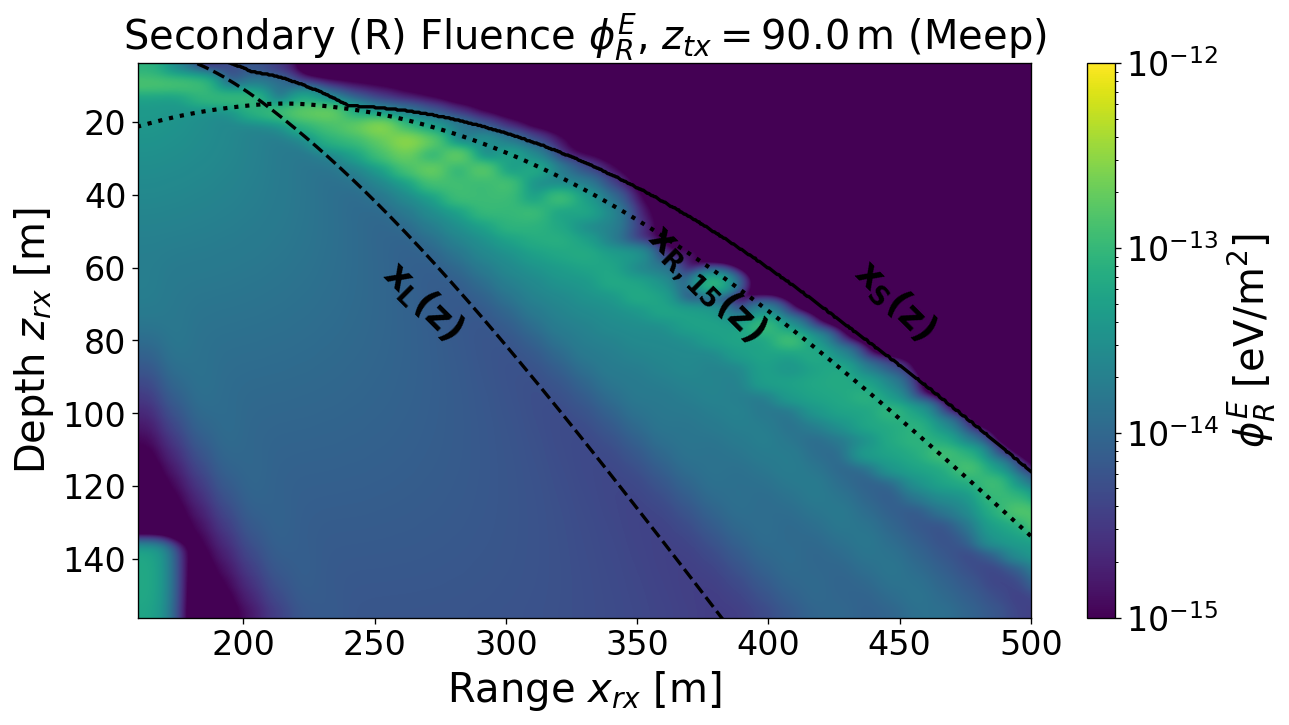

tot_mode False R_mode True fleunce_w shape (1443,)


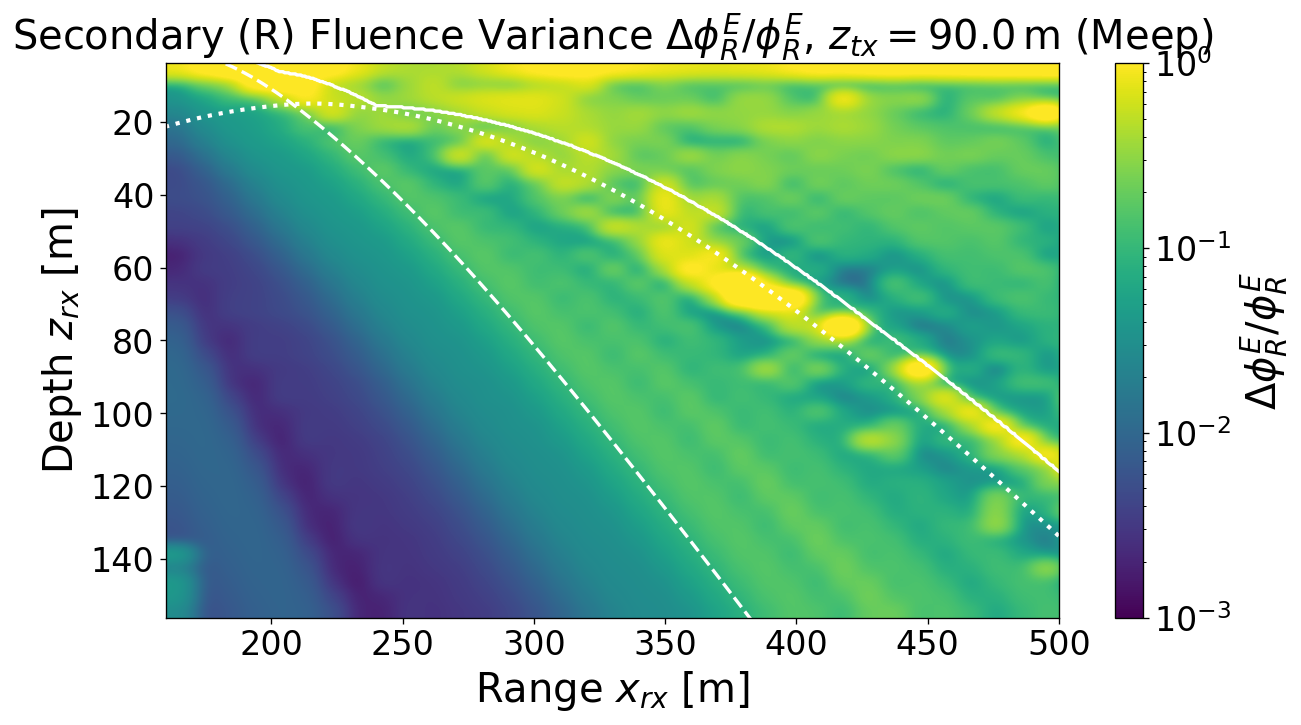

In [42]:
fig, ax = plot_fluence_map(rxFluence_meep, rxList_meep, sourceDepth_meep0, var_mode=False, log_mode=True,ii_select=5,
                           ppp_mode=False, tot_mode=False, R_mode=True, vmax=1e-12, vmin=1e-15, eV_mode=True,
                           map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl],cl_mode=False, show_mode=False, interp_mode='gaussian',
                           figsize=(12,6), fontsize=24, labelsize=20)
ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='k',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='k',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='k',linewidth=2)
txt1 = ax.text(250, 80, label_refl_b,size=22,c='k',rotation=-45)
txt2 = ax.text(350, 80, label_refr_sh_b,size=22,c='k',rotation=-45)
txt3 = ax.text(430, 80, label_shadow_b,size=22,c='k',rotation=-45)
ax.set_ylim(156,4)

fig.savefig(join(path2plot,'meep_R_yrs.png'),bbox_inches='tight')
pl.show()

fig, ax = plot_fluence_map(rxFluence_meep_var, rxList_meep, sourceDepth_meep0, var_mode=True, log_mode=True,
                           show_mode=False, ppp_mode=False, tot_mode=False, R_mode=True, vmax=1, vmin=1e-3, cmap='viridis',
                           path2plots=path2plot, map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl],cl_mode=False, interp_mode='gaussian',
                           figsize=(12,6), fontsize=24, labelsize=20)
ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)
ax.set_ylim(156,4)
fig.savefig(join(path2plot,'meep_var_R_yrs.png'),bbox_inches='tight')
pl.show()

tot_mode False R_mode True fleunce_w shape (1443,)


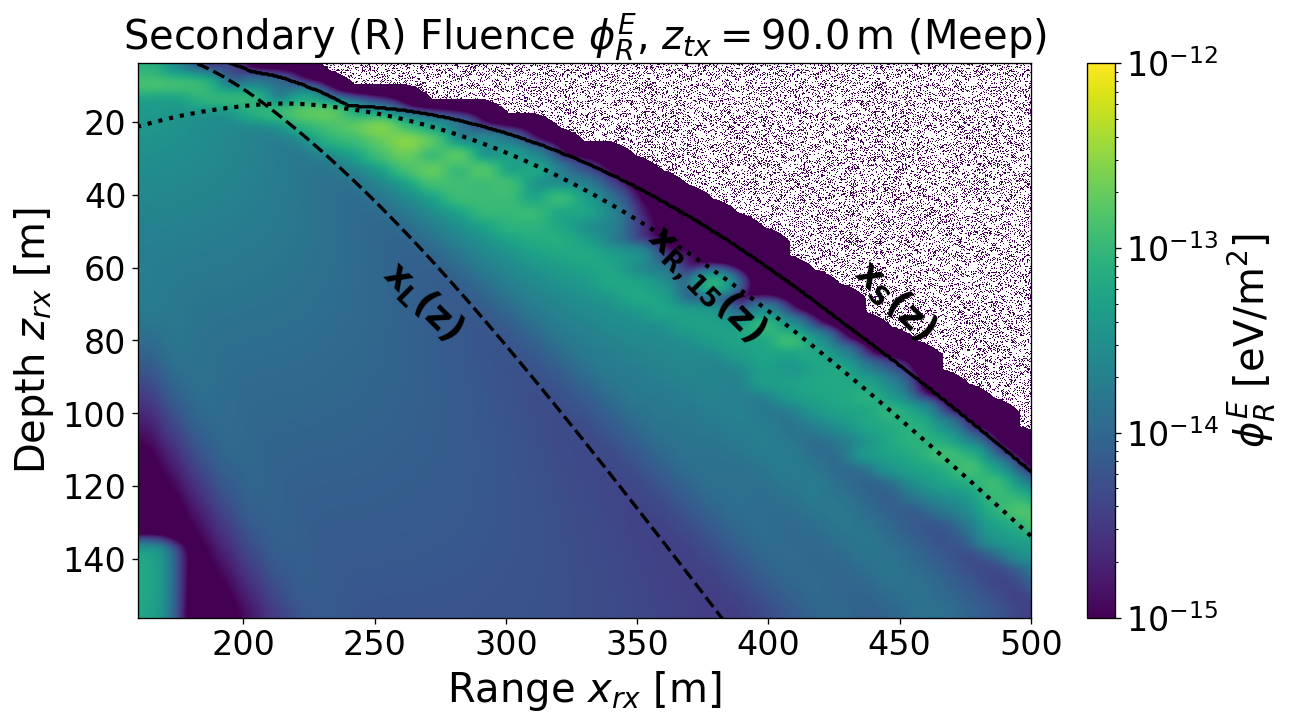

tot_mode False R_mode True fleunce_w shape (1443,)


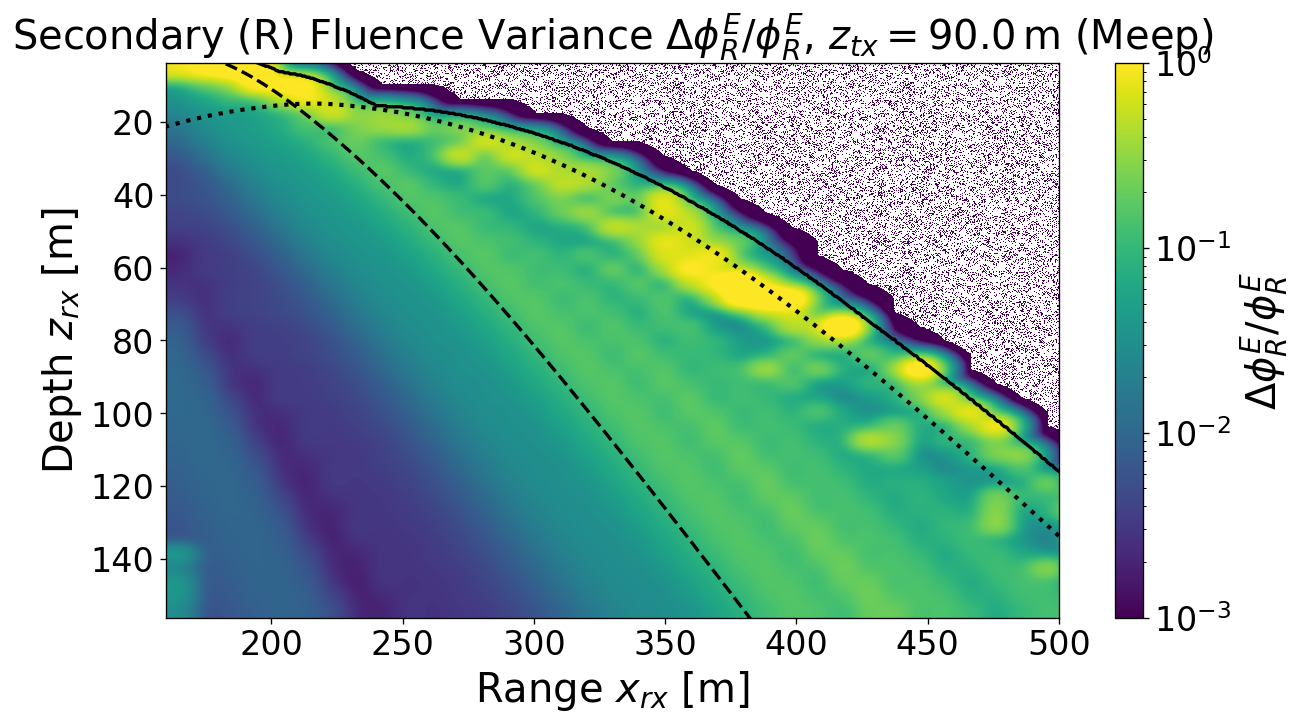

In [43]:
fig, ax = plot_fluence_map_shad(rxFluence_meep, rxList_meep, sourceDepth_meep0, shadow_map=shadow_mode_map, var_mode=False, log_mode=True,ii_select=5,
                                ppp_mode=False, tot_mode=False, R_mode=True, vmax=1e-12, vmin=1e-15, eV_mode=True,
                                map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl],cl_mode=False, show_mode=False, interp_mode='gaussian',
                                figsize=(12,6), fontsize=24, labelsize=20)
ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='k',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='k',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='k',linewidth=2)
txt1 = ax.text(250, 80, label_refl_b,size=22,c='k',rotation=-45)
txt2 = ax.text(350, 80, label_refr_sh_b,size=22,c='k',rotation=-45)
txt3 = ax.text(430, 80, label_shadow_b,size=22,c='k',rotation=-45)
ax.set_ylim(156,4)

#fig.savefig(join(path2plot,'meep_R_yrs.png'),bbox_inches='tight')
pl.show()

fig, ax = plot_fluence_map_shad(rxFluence_meep_var, rxList_meep, sourceDepth_meep0, shadow_map=shadow_mode_map,
                                var_mode=True, log_mode=True,
                                show_mode=False, ppp_mode=False, tot_mode=False, R_mode=True, vmax=1, vmin=1e-3, cmap='viridis',
                                path2plots=path2plot, map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl],cl_mode=False, interp_mode='gaussian',
                                figsize=(12,6), fontsize=24, labelsize=20)
ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='k',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='k',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='k',linewidth=2)
ax.set_ylim(156,4)
#fig.savefig(join(path2plot,'meep_var_R_yrs.png'),bbox_inches='tight')
pl.show()

R_mode True fluence_w shape (1443, 2)


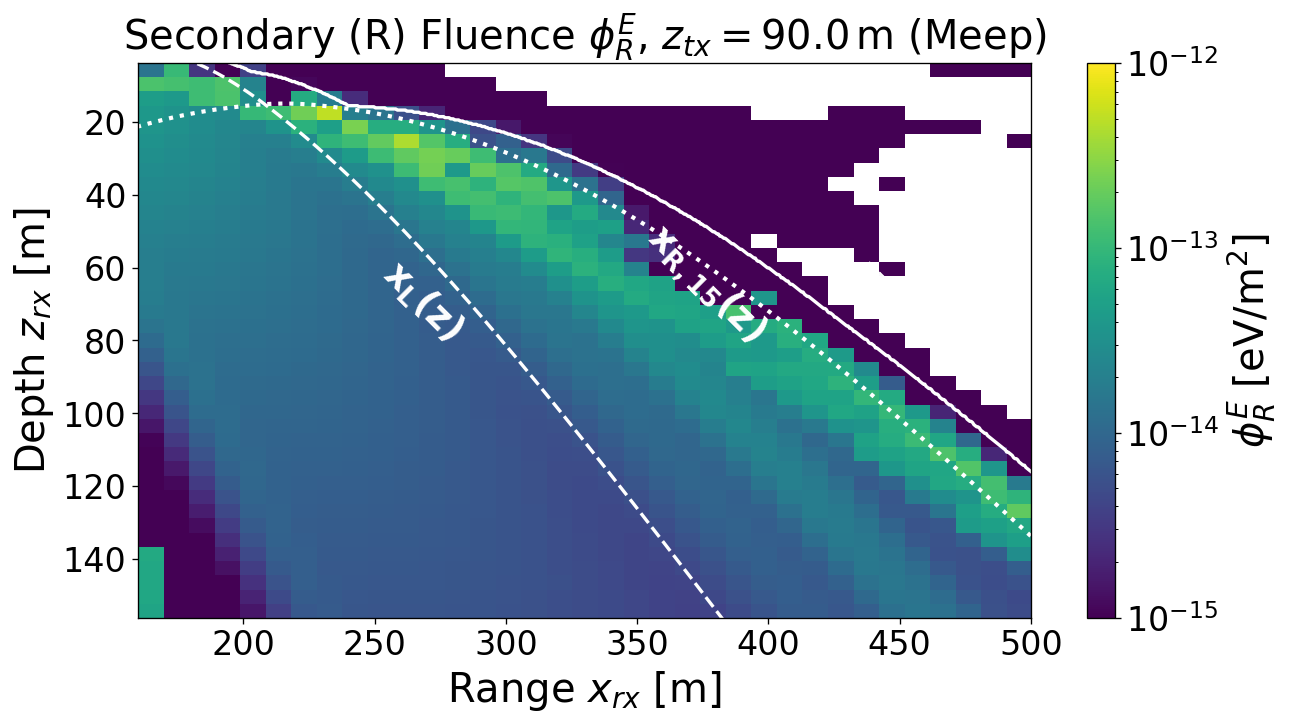

R_mode True fluence_w shape (1443, 2)


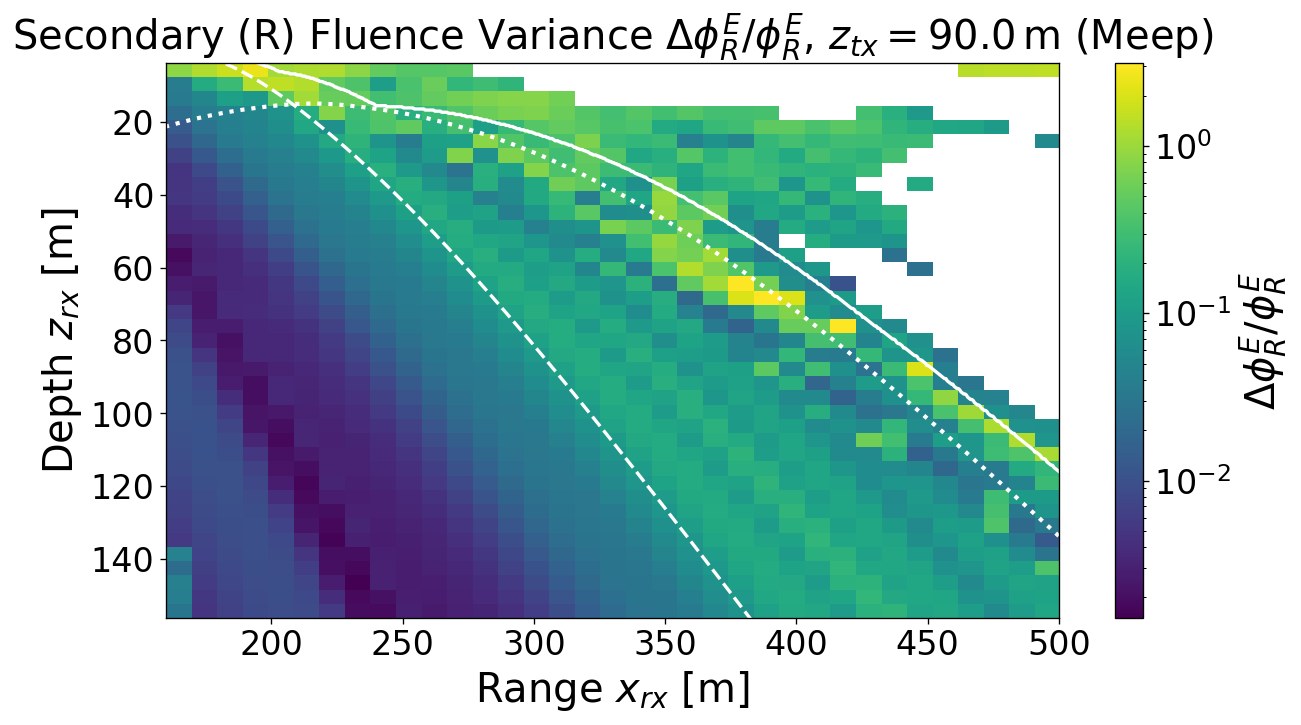

R_mode False fluence_w shape (1443, 2)


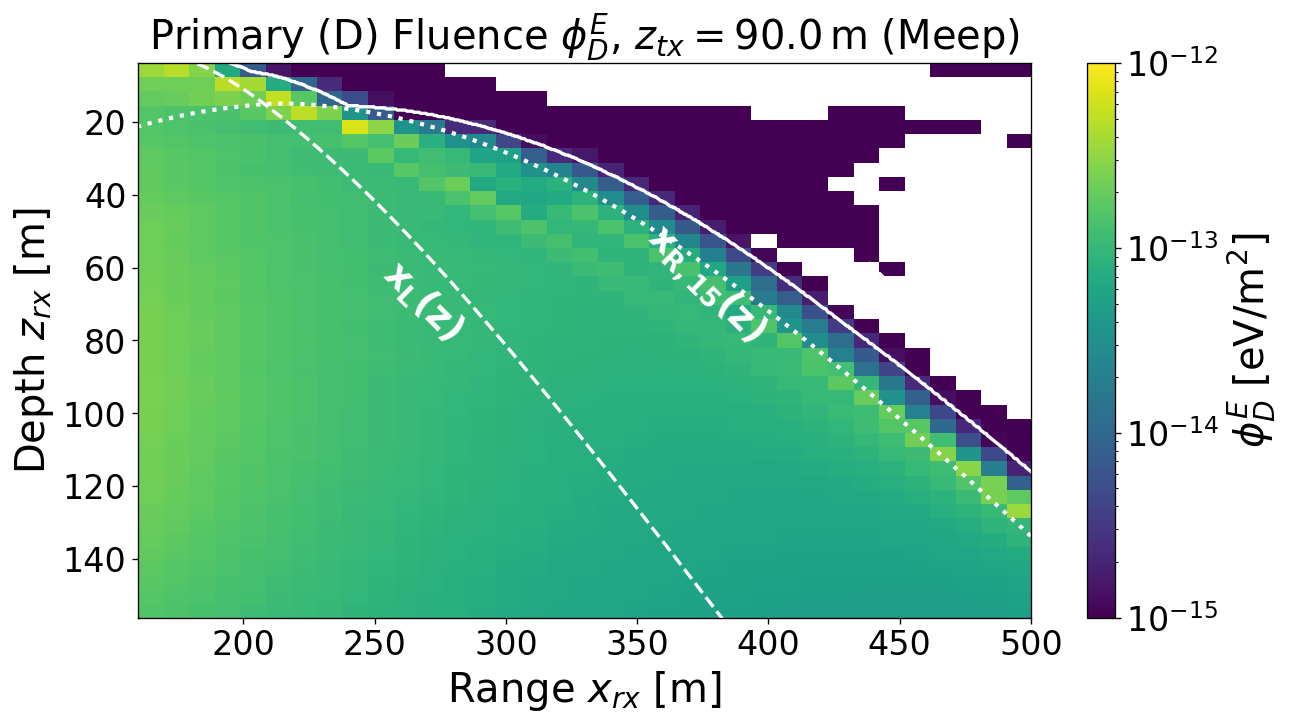

R_mode False fluence_w shape (1443, 2)


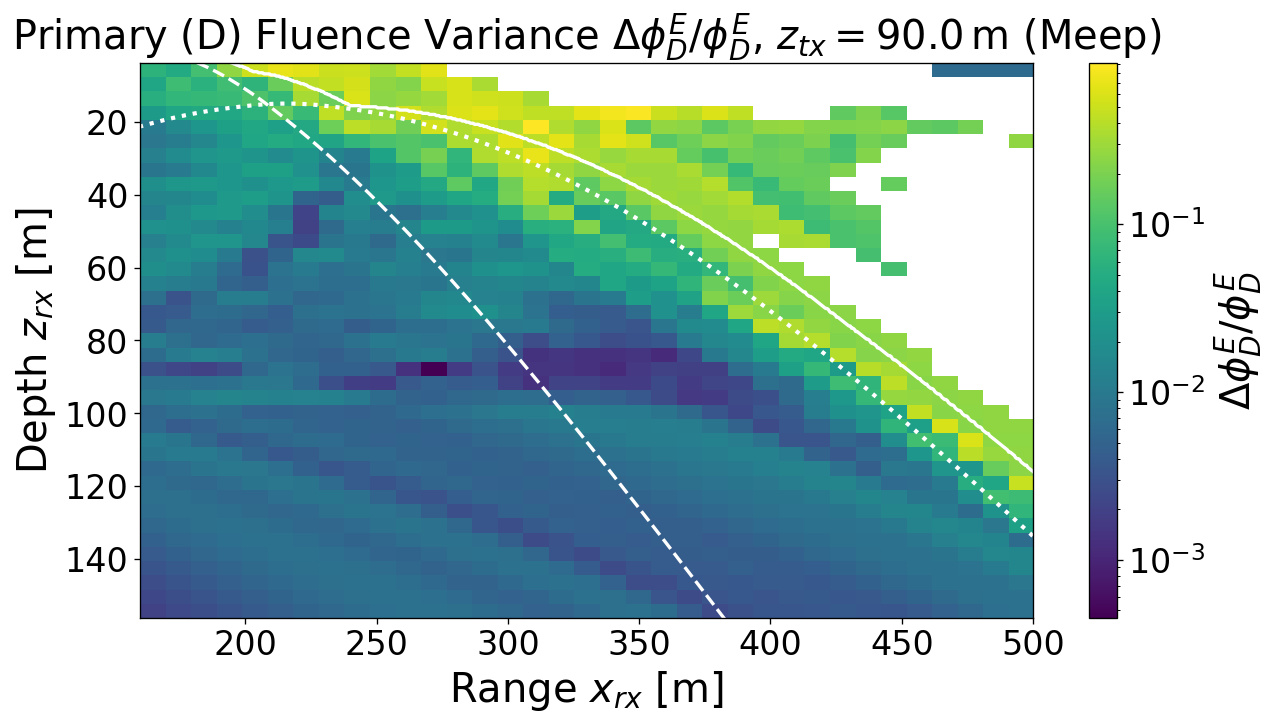

In [44]:
ii_select_control = 0
fig, ax = plot_fluence_map_both(rxFluence_meep_var, rxFluence_meep, rxFluence_meep_tot, 
                                rxList_meep, sourceDepth_meep0, var_mode=False, log_mode=True,ii_select=ii_select_control,
                                ppp_mode=False, R_mode=True, vmax=1e-12, vmin=1e-15, eV_mode=True,
                                map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl],cl_mode=False, show_mode=False, interp_mode='nearest',
                                figsize=(12,6), fontsize=24, labelsize=20)
ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)
txt1 = ax.text(250, 80, label_refl_b,size=22,c='w',rotation=-45)
txt2 = ax.text(350, 80, label_refr_sh_b,size=22,c='w',rotation=-45)
txt3 = ax.text(430, 80, label_shadow_b,size=22,c='w',rotation=-45)
ax.set_ylim(156,4)
#fig.savefig(join(path2plot,'meep_R_yrs.png'),bbox_inches='tight')
pl.show()

fig, ax = plot_fluence_map_both(rxFluence_meep_var, rxFluence_meep, rxFluence_meep_tot, 
                                rxList_meep, sourceDepth_meep0, var_mode=True, log_mode=True,ii_select=ii_select_control, ppp_mode=False,
                                show_mode=False, R_mode=True, vmax=None, vmin=None, cmap='viridis',
                                path2plots=path2plot, map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl],cl_mode=False, interp_mode='nearest',
                                figsize=(12,6), fontsize=24, labelsize=20)
ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)
ax.set_ylim(156,4)
#fig.savefig(join(path2plot,'meep_var_R_yrs.png'),bbox_inches='tight')
pl.show()

ii_select_control = 0
fig, ax = plot_fluence_map_both(rxFluence_meep_var, rxFluence_meep, rxFluence_meep_tot, 
                                rxList_meep, sourceDepth_meep0, var_mode=False, log_mode=True,ii_select=ii_select_control,
                                ppp_mode=False, R_mode=False, vmax=1e-12, vmin=1e-15, eV_mode=True,
                                map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl],cl_mode=False, show_mode=False, interp_mode='nearest',
                                figsize=(12,6), fontsize=24, labelsize=20)
ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)
txt1 = ax.text(250, 80, label_refl_b,size=22,c='w',rotation=-45)
txt2 = ax.text(350, 80, label_refr_sh_b,size=22,c='w',rotation=-45)
txt3 = ax.text(430, 80, label_shadow_b,size=22,c='w',rotation=-45)
ax.set_ylim(156,4)
#fig.savefig(join(path2plot,'meep_R_yrs.png'),bbox_inches='tight')
pl.show()

fig, ax = plot_fluence_map_both(rxFluence_meep_var, rxFluence_meep, rxFluence_meep_tot, 
                                rxList_meep, sourceDepth_meep0, var_mode=True, log_mode=True,ii_select=ii_select_control, ppp_mode=False,
                                show_mode=False, R_mode=False, vmax=None, vmin=None, cmap='viridis',
                                path2plots=path2plot, map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl],cl_mode=False, interp_mode='nearest',
                                figsize=(12,6), fontsize=24, labelsize=20)
ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)
ax.set_ylim(156,4)
#fig.savefig(join(path2plot,'meep_var_R_yrs.png'),bbox_inches='tight')
pl.show()

shape of rxPulses (11, 1443)
tot_mode True R_mode True fleunce_w shape (1443,)


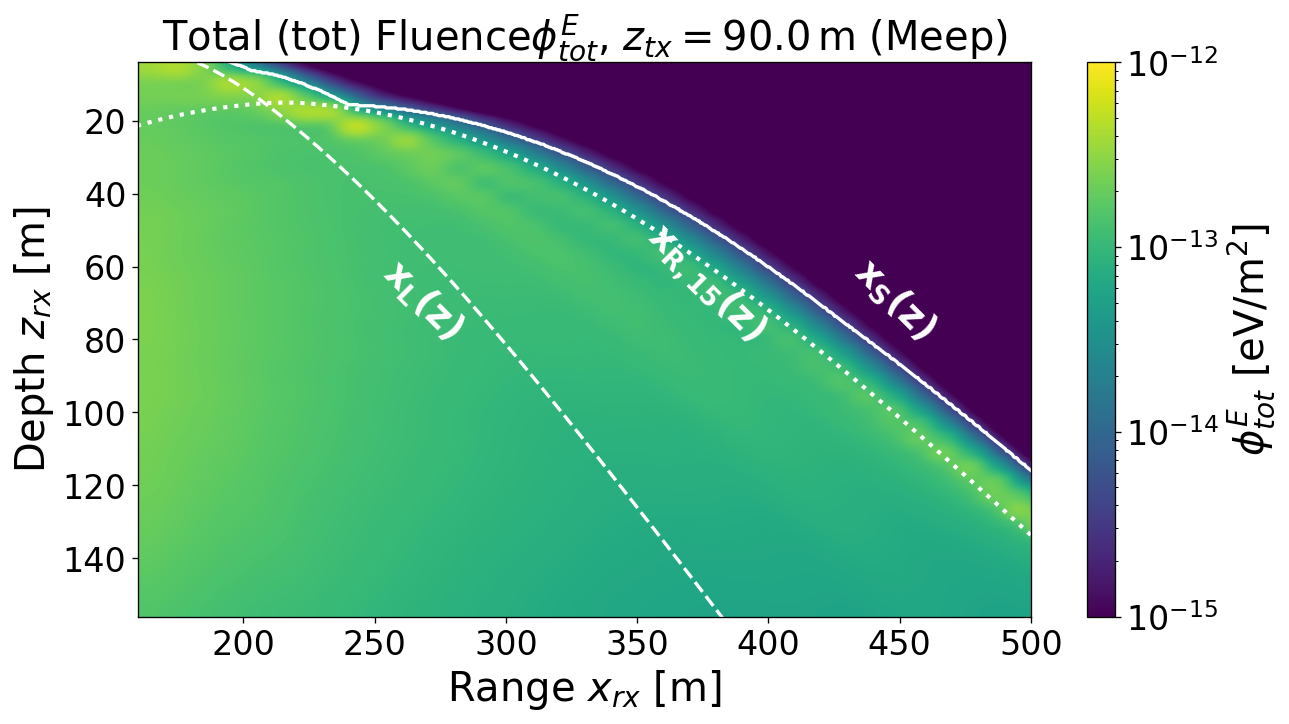

tot_mode True R_mode True fleunce_w shape (1443,)


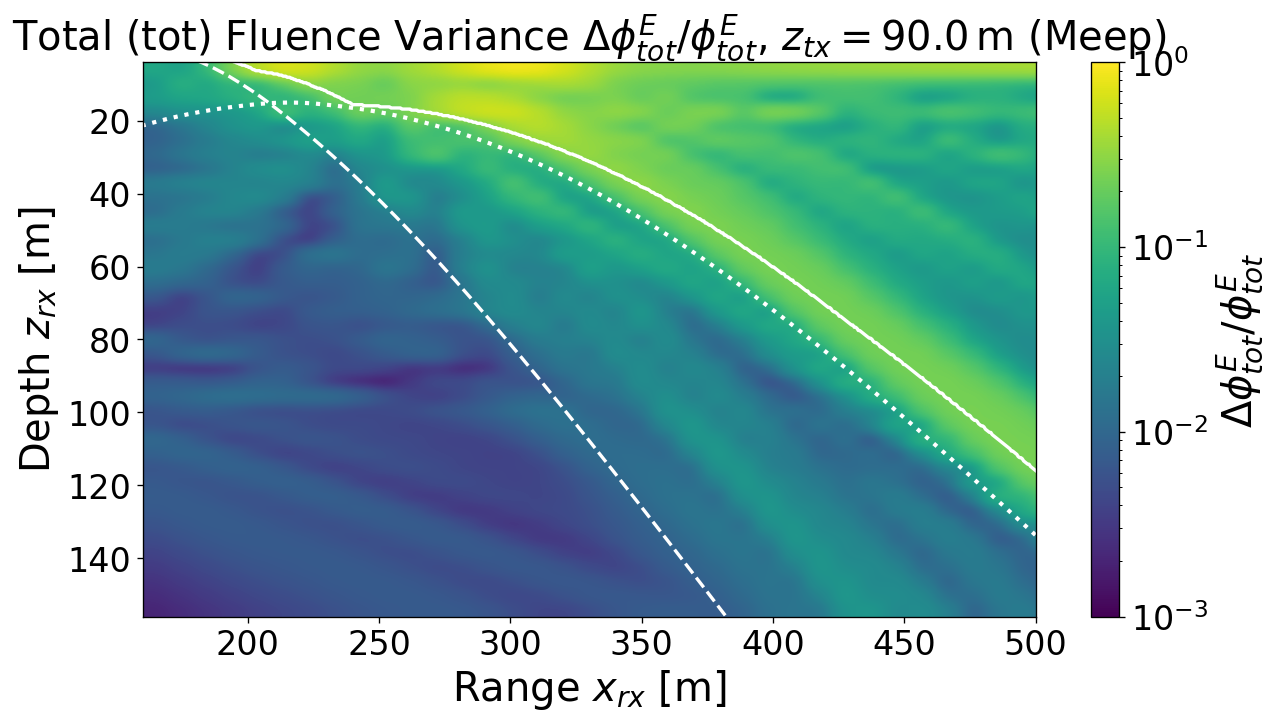

In [45]:
fig, ax = plot_fluence_map(rxFluence_meep_tot, rxList_meep, sourceDepth_meep0, var_mode=False, log_mode=True,
                           ppp_mode=False, tot_mode=True, R_mode=True, vmax=1e-12, vmin=1e-15, eV_mode=True,
                           map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl],cl_mode=False, show_mode=False, interp_mode='gaussian',
                           figsize=(12,6), fontsize=24, labelsize=20)
ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)
txt1 = ax.text(250, 80, label_refl_b,size=22,c='w',rotation=-45)
txt2 = ax.text(350, 80, label_refr_sh_b,size=22,c='w',rotation=-45)
txt3 = ax.text(430, 80, label_shadow_b,size=22,c='w',rotation=-45)

ax.set_ylim(156,4)
'''
legend = ax.legend(fontsize=12,loc=(0, 0))
legend.get_frame().set_alpha(1)
'''
fig.savefig(join(path2plot,'meep_tot_yrs.png'),bbox_inches='tight')
pl.show()

fig, ax = plot_fluence_map(rxFluence_meep_tot_var, rxList_meep, sourceDepth_meep0, var_mode=True, log_mode=True,
                           show_mode=False, ppp_mode=False, tot_mode=True, R_mode=True, vmax=1, vmin=1e-3, cmap='viridis',
                           path2plots=path2plot, map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl],cl_mode=False, interp_mode='gaussian',
                           figsize=(12,6), fontsize=24, labelsize=20)
ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)
ax.set_ylim(156,4)
'''
legend = ax.legend(fontsize=12,loc=(0, 0))
legend.get_frame().set_alpha(1)
'''
fig.savefig(join(path2plot,'meep_var_tot_years.png'),bbox_inches='tight')
pl.show()

In [ ]:
fig, ax = plot_fluence_map_both(rxFluence_meep_var, rxFluence_meep, rxFluence_meep_tot, 
                                rxList_meep, sourceDepth_meep0, var_mode=False, log_mode=True,ii_select=5,
                                ppp_mode=False, R_mode=False, vmax=1e-12, vmin=1e-15, eV_mode=True,
                                map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl],cl_mode=False, show_mode=False, interp_mode='gaussian',
                                figsize=(12,6), fontsize=24, labelsize=20)
ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)
txt1 = ax.text(250, 80, label_refl_b,size=22,c='w',rotation=-45)
txt2 = ax.text(350, 80, label_refr_sh_b,size=22,c='w',rotation=-45)
txt3 = ax.text(430, 80, label_shadow_b,size=22,c='w',rotation=-45)
ax.set_ylim(156,4)
#fig.savefig(join(path2plot,'meep_R_yrs.png'),bbox_inches='tight')
pl.show()

fig, ax = plot_fluence_map_both(rxFluence_meep_var, rxFluence_meep, rxFluence_meep_tot, 
                                rxList_meep, sourceDepth_meep0, var_mode=True, log_mode=True,ii_select=5, ppp_mode=False,
                                show_mode=False, R_mode=False, vmax=None, vmin=None, cmap='viridis',
                                path2plots=path2plot, map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl],cl_mode=False, interp_mode='gaussian',
                                figsize=(12,6), fontsize=24, labelsize=20)
ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)
ax.set_ylim(156,4)
#fig.savefig(join(path2plot,'meep_var_R_yrs.png'),bbox_inches='tight')
pl.show()

In [ ]:
# Calculate Time Variance
from fluence_analysis import get_tpeak_matrix, get_tpeak_matrix_l, plot_t_map

time_arr_out, rxList_t_out = get_tpeak_matrix_l(rxPulses_meep_l, rxList_meep, tspace_meep0,
                                                t_cut=t_cut, t_ratio=t_ratio, t_limit_in = t_limit_arr,
                                                ppp_mode=False)
rxTime_meep_var = calculate_variance_matrix(time_arr_out, t_mode=True)

In [ ]:
print(rxTime_meep_var.shape, rxList_meep.shape, shadow_mode_map.shape, nRx)
rxTime_meep_var2 = np.zeros(rxTime_meep_var.shape)
for i in range(nRx):
    if shadow_mode_map[i] == 1:
        for j in range(2):
            rxTime_meep_var2[i,j] = rxTime_meep_var[i,j]
    else:
        for j in range(2):
            rxTime_meep_var2[i,j] = np.nan

In [ ]:
fig, ax = plot_t_map(rxTime_meep_var2, rxList_meep, sourceDepth_meep0, var_mode=True, log_mode=True,
                     ppp_mode=False, tot_mode=False, R_mode=False, vmax=5, vmin=1e-1, cmap='viridis',
                     map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl], interp_mode='gaussian',
                     cl_mode=False, show_mode=False)

ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)

ax.legend(fontsize=12,loc='lower left')
fig.savefig(join(path2plot,'t_D_years.png'),bbox_inches='tight')
pl.show()

fig, ax = plot_t_map(rxTime_meep_var2, rxList_meep, sourceDepth_meep0, var_mode=True, log_mode=True,
                     ppp_mode=False, tot_mode=False, R_mode=True, vmax=5, vmin=1e-1, cmap='viridis',
                     map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl], interp_mode='gaussian',
                     cl_mode=False, show_mode=False)

ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)

ax.legend(fontsize=12,loc='lower left')
fig.savefig(join(path2plot,'t_R_years.png'),bbox_inches='tight')
pl.show()

fig, ax = plot_t_map(rxTime_meep_var2, rxList_meep, sourceDepth_meep0, var_mode=True, log_mode=False,
                     ppp_mode=False, tot_mode=False, R_mode=False, vmax=5, vmin=0, cmap='viridis',
                     map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl], interp_mode='gaussian',
                     cl_mode=False, show_mode=False)

ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)

ax.legend(fontsize=12,loc='lower left')
fig.savefig(join(path2plot,'t_D_years.png'),bbox_inches='tight')
pl.show()

fig, ax = plot_t_map(rxTime_meep_var2, rxList_meep, sourceDepth_meep0, var_mode=True, log_mode=False,
                     ppp_mode=False, tot_mode=False, R_mode=True, vmax=5, vmin=0, cmap='viridis',
                     map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl], interp_mode='gaussian',
                     cl_mode=False, show_mode=False)

ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)

ax.legend(fontsize=12,loc='lower left')
fig.savefig(join(path2plot,'t_R_years.png'),bbox_inches='tight')
pl.show()

In [ ]:
fig, ax = plot_t_map(rxTime_meep_var, rxList_meep, sourceDepth_meep0, var_mode=True, log_mode=True,
                     ppp_mode=False, tot_mode=False, R_mode=False, vmax=1e1, vmin=1e-1, cmap='viridis',
                     map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl], interp_mode='gaussian',
                     cl_mode=False, show_mode=False)

ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)

ax.legend(fontsize=12,loc='lower left')
fig.savefig(join(path2plot,'t_D_years.png'),bbox_inches='tight')
pl.show()

fig, ax = plot_t_map(rxTime_meep_var, rxList_meep, sourceDepth_meep0, var_mode=True, log_mode=True,
                     ppp_mode=False, tot_mode=False, R_mode=True, vmax=1e1, vmin=1e-1, cmap='viridis',
                     map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl], interp_mode='gaussian',
                     cl_mode=False, show_mode=False)

ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)

ax.legend(fontsize=12,loc='lower left')
fig.savefig(join(path2plot,'t_R_years.png'),bbox_inches='tight')
pl.show()

In [ ]:
fig, ax = plot_dt_map(rxTime_meep_var, rxList_meep, sourceDepth_meep0, var_mode=True, log_mode=True,
                     ppp_mode=False, vmax=10, vmin=1e-1, cmap='viridis',
                      map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl], interp_mode='gaussian',
                     cl_mode=False, show_mode=False,
                     fontsize=22, labelsize=18)
ax.set_title('Relative time offset $\Delta t_{DR}$ variance, $z_{tx} = 90.0 \, \mathrm{m}$ (Meep)',fontsize=22)
ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='w',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='w',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='w',linewidth=2)
ax.set_ylim(155,4)

#ax.legend(fontsize=12,loc='lower left')
fig.savefig(join(path2plot,'dt_DR_years.png'),bbox_inches='tight')
pl.show()

fig, ax = plot_dt_map2(rxTime_meep_var, rxList_meep, sourceDepth_meep0, var_mode=True, log_mode=True,
                     ppp_mode=False, vmax=10, vmin=1e-1, cmap='viridis',
                      map_cut=[X_min_pl, X_max_pl, Z_min_pl, Z_max_pl], interp_mode='gaussian',
                     cl_mode=False, show_mode=False, fontsize=24, labelsize=20, figsize=(12,6))


ax.set_title('Relative time offset $\Delta t_{DR}$ variance, $z_{tx} = 90.0 \, \mathrm{m}$ (Meep)',fontsize=22)
txt1 = ax.text(250, 80, label_refl_b,size=22,c='k',rotation=-45)
txt2 = ax.text(350, 80, label_refr_sh_b,size=22,c='k',rotation=-45)
txt3 = ax.text(430, 80, label_shadow_b,size=22,c='k',rotation=-45)
ax.axvline(np.nan, linestyle='--', color='k',label=label_refl,linewidth=2)
ax.axvline(np.nan, linestyle=':', c='k',label=label_refr_sh,linewidth=2.5)
ax.axvline(np.nan, linestyle='-', c='k',label=label_shadow,linewidth=2)
ax.plot(x_path_z0, -1*z_path_z0, '--', c='k',linewidth=2)
ax.plot(x_path_z15, -1*z_path_z15, ':', c='k',linewidth=2.5)
ax.plot(x_shadow, -1*np.array(z_shadow), c='k',linewidth=2)
ax.set_ylim(155,4)
#ax.legend(fontsize=12,loc='lower left')
fig.savefig(join(path2plot,'dt_DR_years2.png'),bbox_inches='tight')
pl.show()

In [ ]:
rxTime_D_var_meep0 = [] # reflection
rxTime_D_var_meep1 = [] # Refraction
rxTime_D_var_meep2 = [] # Refraction

rxTime_R_var_meep0 = [] # reflection
rxTime_R_var_meep1 = [] # Refraction
rxTime_R_var_meep2 = [] # Refraction

Time_var_refr = 0
for i in range(nRx):
    x_rx = rxList_meep[i,0]
    z_rx = rxList_meep[i,1]

    ii_x0 = findNearest(x_rx, x_path_z0)
    ii_x15 = findNearest(x_rx, x_path_z15)
    ii_xsh = findNearest(x_rx, x_shadow)
    
    x_guess0 = x_path_z0[ii_x0]
    z_guess0 = -1*z_path_z0[ii_x0]

    x_guess15 = x_path_z15[ii_x15]
    z_guess15 = -1*z_path_z15[ii_x15]

    x_guess_sh = x_shadow[ii_xsh]
    z_guess_sh = -1*z_shadow[ii_xsh]
    #print(z_guess_sh)

    if z_rx < z_guess_sh: # and z_rx > 15:
        rxTime_D_var_meep2.append(rxTime_meep_var[i,0])
        rxTime_R_var_meep2.append(rxTime_meep_var[i,1])
    else:
        if z_rx >= z_guess0:# and z_rx > 15:
            rxTime_D_var_meep0.append(rxTime_meep_var[i,0])
            rxTime_R_var_meep0.append(rxTime_meep_var[i,1])
        else:
            if z_rx <= z_guess15 and x_rx >= 250: #and z_rx < 15:
                pass
            else:
                rxTime_D_var_meep1.append(rxTime_meep_var[i,0])
                rxTime_R_var_meep1.append(rxTime_meep_var[i,1])
rxTime_DR_var_meep0 = np.array(rxTime_D_var_meep0) + np.array(rxTime_R_var_meep0)
rxTime_DR_var_meep1 = np.array(rxTime_D_var_meep1) + np.array(rxTime_R_var_meep1)
rxTime_DR_var_meep2 = np.array(rxTime_D_var_meep2) + np.array(rxTime_R_var_meep2)

'''
ax.bar(x_cent, hist1d_lin_var_meep_2/sum_total, width=x_width/float(nBins), label='Shadow',alpha=1,color='b')
ax.bar(x_cent, hist1d_lin_var_meep_1/sum_total, width=x_width/float(nBins), label='Refraction',alpha=0.5,color='orange')
ax.bar(x_cent, hist1d_lin_var_meep_0/sum_total, width=x_width/float(nBins), label='Reflection',alpha=0.5,color='g')
'''
nBins = 80
x_min = 0
x_max = 20
range_t = (x_min,x_max)
x_width = (x_max-x_min)
hist1d_var_time2, x_bins = np.histogram(rxTime_DR_var_meep2, bins=nBins, range=range_t)
hist1d_var_time1, x_bins = np.histogram(rxTime_DR_var_meep1, bins=nBins, range=range_t)
hist1d_var_time0, x_bins = np.histogram(rxTime_DR_var_meep0, bins=nBins, range=range_t)

x_cent = (x_bins[1:] + x_bins[:-1]) /2
sum_total = np.sum(hist1d_var_time0) + np.sum(hist1d_var_time1) + np.sum(hist1d_var_time2)

fig = pl.figure(figsize=(10,6),dpi=120)
ax = fig.add_subplot(111)
#ax.bar(x_cent, hist1d_var_time2/sum_total, width=x_width/float(nBins), label='Shadow',alpha=1,color='b')
ax.bar(x_cent, hist1d_var_time0/sum_total, width=x_width/float(nBins), label='Reflection',alpha=0.5,color='g')
ax.bar(x_cent, hist1d_var_time1/sum_total, width=x_width/float(nBins), label='Refraction',alpha=0.5,color='orange')
print(np.nanmean(rxTime_DR_var_meep0), np.nanmedian(rxTime_DR_var_meep0))
print(np.nanmean(rxTime_DR_var_meep1), np.nanmedian(rxTime_DR_var_meep1))
#print(np.nanmean(rxTime_DR_var_meep2), np.nanmedian(rxTime_DR_var_meep2))

ax.axvline(np.nan,color='k', label='Median',linestyle='dashdot')
ax.axvline(np.nan,color='k', label='Mean',linestyle=':')

#ax.axvline(np.nanmedian(rxTime_DR_var_meep2),color='b',linestyle='dashdot')
ax.axvline(np.nanmedian(rxTime_DR_var_meep1),color='orange',linestyle='dashdot')
ax.axvline(np.nanmedian(rxTime_DR_var_meep0),color='g',linestyle='dashdot')

#ax.axvline(np.nanmean(rxTime_DR_var_meep2),color='b',linestyle=':')
#ax.axvline(np.nanmean(rxTime_DR_var_meep1),color='orange',linestyle=':')
#ax.axvline(np.nanmean(rxTime_DR_var_meep0),color='g',linestyle=':')
ax.set_xlabel('$\Delta(\Delta t_{DR})$ [ns]',fontsize=fontsize)
ax.set_ylabel('$N_{RX}/N_{tot,RX}$',fontsize=fontsize)
ax.tick_params(axis='both', labelsize=labelsize)
ax.set_yscale('log')
ax.legend()
fig.savefig('dt_DR_hist1d.png',bbox_inches='tight')
pl.show()